# Predicting 10 Year Risk of Heart Disease

## Introduction
Coronary Heart Disease (CHD) is one of the leading causes of mortality worldwide, making early risk identification a central objective in preventative medicine. Accurate prediction of an individual's likelihood of developing CHD enables targeted intervention that can substantially reduce the individuals' risk of adverse coronary outcomes. From a modeling perspective, this problem is formulated as a supervised binary classification task, where the goal is to estimate the probability that a patient will experience a CHD event in a time horizon of 10 years.

The primary objective of this project is to develop and evaluate machine learning models for CHD risk prediction using the Framingham Heart Study Dataset. The overall objectives of this project are as follows:
1. Data Exploration and Cleaning: Thoroughly explore the dataset of its structure and variables to identify distributions as well as address missing data.

2. Data Preprocessing: Construct a robust data preprocessing and feature engineering pipeline.

3. Model Building: implement and compare multiple classification models, including both classical and modern approaches to predict ten year CHD risk.

4. Model Evaluation: Evaluate model performance using appropriate evaluation metrics to assess predictive ability, and interpret results to identify key risk factors associated with CHD

## Dataset Description
The Framingham Heart Study Dataset contains information on several health related variables of each individual participant. These variables consist of:
### Demographic Variables
- male: biological sex of the partipant (Categorical)
    - male = 1
    - female = 0
- age: the age of the participant (Continuous)
- education: the highest completed education level of the participant (Ordinal)
    - High School = 1
    - Undergraduate = 2
    - Post Graduate = 3
    - PHD = 4

### Behavioural 
- currentSmoker: denotes whether the participant is an active smoker or not (Categorical)
    - yes = 1
    - no = 0
- cigsPerDay: the number of cigarettes the participant uses on average in a day (Discrete)

### Medical
- BPMeds: denotes whether the participant is a user of blood pressure medication (Binary)
    - yes = 1
    - no = 0
- prevalentStroke: denotes whether the participant has previously experienced a stroke (Binary)
    - yes = 1
    - no = 0
- prevalentHyp: denotes whether the participant is hypertensive (Binary)
    - yes = 1
    - no = 0
- diabetes: denotes whether the participant has diabetes (Binary)
    - yes = 1
    - no = 0
- totChol: total cholesterol level (Continuous)
- sysBP: systolic blood pressure (Continuous)
- diaBP: diastolic blood pressure (Continuous)
- BMI: Body Mass Index (Continuous)
- heartRate: heart rate (Continuous)
- glucose: glucose level (Continuous)

### Target Variable
- TenYearCHD: 10-year risk of coronary heart disease CHD (Binary)



### Imports

In [10]:
import warnings
warnings.filterwarnings("ignore")

In [11]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [12]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [13]:
# data analysis
import numpy as np
import pandas as pd

# data visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import chi2
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# machine learning
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

# evaluation 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_auc_score,roc_curve


In [14]:
# loading the dataset
df = pd.read_csv("../data/framingham_kaggle.csv")

# check proper load
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [15]:
df.sample(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1084,1,45,2.0,0,0.0,0.0,0,0,0,232.0,122.5,82.5,27.55,74.0,59.0,1
510,0,53,2.0,0,0.0,0.0,0,0,0,235.0,132.0,84.0,30.10,80.0,63.0,0
396,1,39,3.0,0,0.0,0.0,0,0,0,202.0,136.5,79.0,24.35,73.0,60.0,0
2903,0,57,1.0,1,20.0,0.0,0,0,0,174.0,120.0,62.0,25.13,95.0,77.0,1
1786,0,54,1.0,0,0.0,0.0,0,1,0,293.0,132.0,84.0,26.81,80.0,NaN,0


In [16]:
# dataset overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


## Data Preprocessing

In [17]:
# Checking Missing Values
missing_data = df.isnull().sum()
missing_data = missing_data.to_frame(name='absolute')
missing_data['relative'] = round((missing_data['absolute']/len(df)), 3)
total_relative = round(((missing_data['absolute'].sum()/df.shape[0]) * 100), 2)
print(missing_data)
print(f"total percentage of missing data: {total_relative}")

                 absolute  relative
male                    0     0.000
age                     0     0.000
education             105     0.025
currentSmoker           0     0.000
cigsPerDay             29     0.007
BPMeds                 53     0.012
prevalentStroke         0     0.000
prevalentHyp            0     0.000
diabetes                0     0.000
totChol                50     0.012
sysBP                   0     0.000
diaBP                   0     0.000
BMI                    19     0.004
heartRate               1     0.000
glucose               388     0.092
TenYearCHD              0     0.000
total percentage of missing data: 15.21


In [18]:
# Drop missing data
df.dropna(axis=0,inplace=True)
df.shape

(3658, 16)

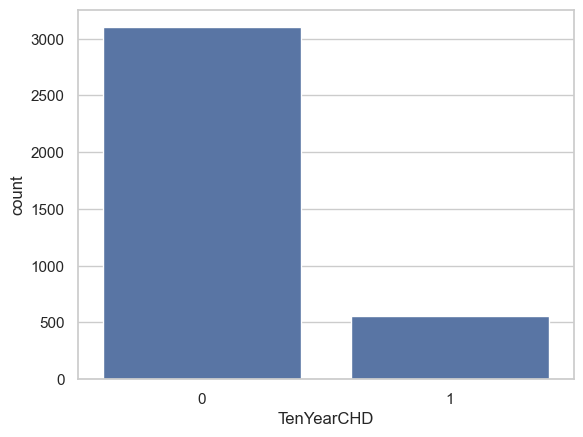

In [19]:
sns.set_theme(style="whitegrid")
sns.countplot(x="TenYearCHD", data=df)
plt.show()

In [20]:
df['TenYearCHD'].value_counts(normalize=True)

TenYearCHD
0    0.847731
1    0.152269
Name: proportion, dtype: float64

As shown, there is a significant class imbalance between participants without risk of CHD compared to participants at risk in a time span of 10 years. This imbalance should be accounted for when developing the models as it can affect performance and interpretation.

## Exploratory Data Analysis

### Univariate Analysis

In [21]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000
mean,0.443685,49.551941,1.980317,0.489065,9.025424,0.030344,0.005741,0.311646,0.027064,236.847731,132.370558,82.917031,25.782802,75.730727,81.852925,0.152269
std,0.496886,8.562029,1.022656,0.499949,11.921590,0.171557,0.075561,0.463229,0.162292,44.097681,22.086866,11.974258,4.065601,11.981525,23.904164,0.359331
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,143.875000,90.000000,28.037500,82.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Some figures of note:
- the participants have an average age of 49 years, with the youngest participant being 32 and the oldest being 70.
- the particpants have an average BMI of 25.78, which typically falls into the category of overweight (between 25 and 30), so the overall study population is slightly overweight. Additionally, it's worth noting that BMI values above 30 are considered obese. 
- the average glucose level is 81, which does fall in the normal range of glucose levels. This indicates that among study participants the distribution of glucose levels is generally healthy.

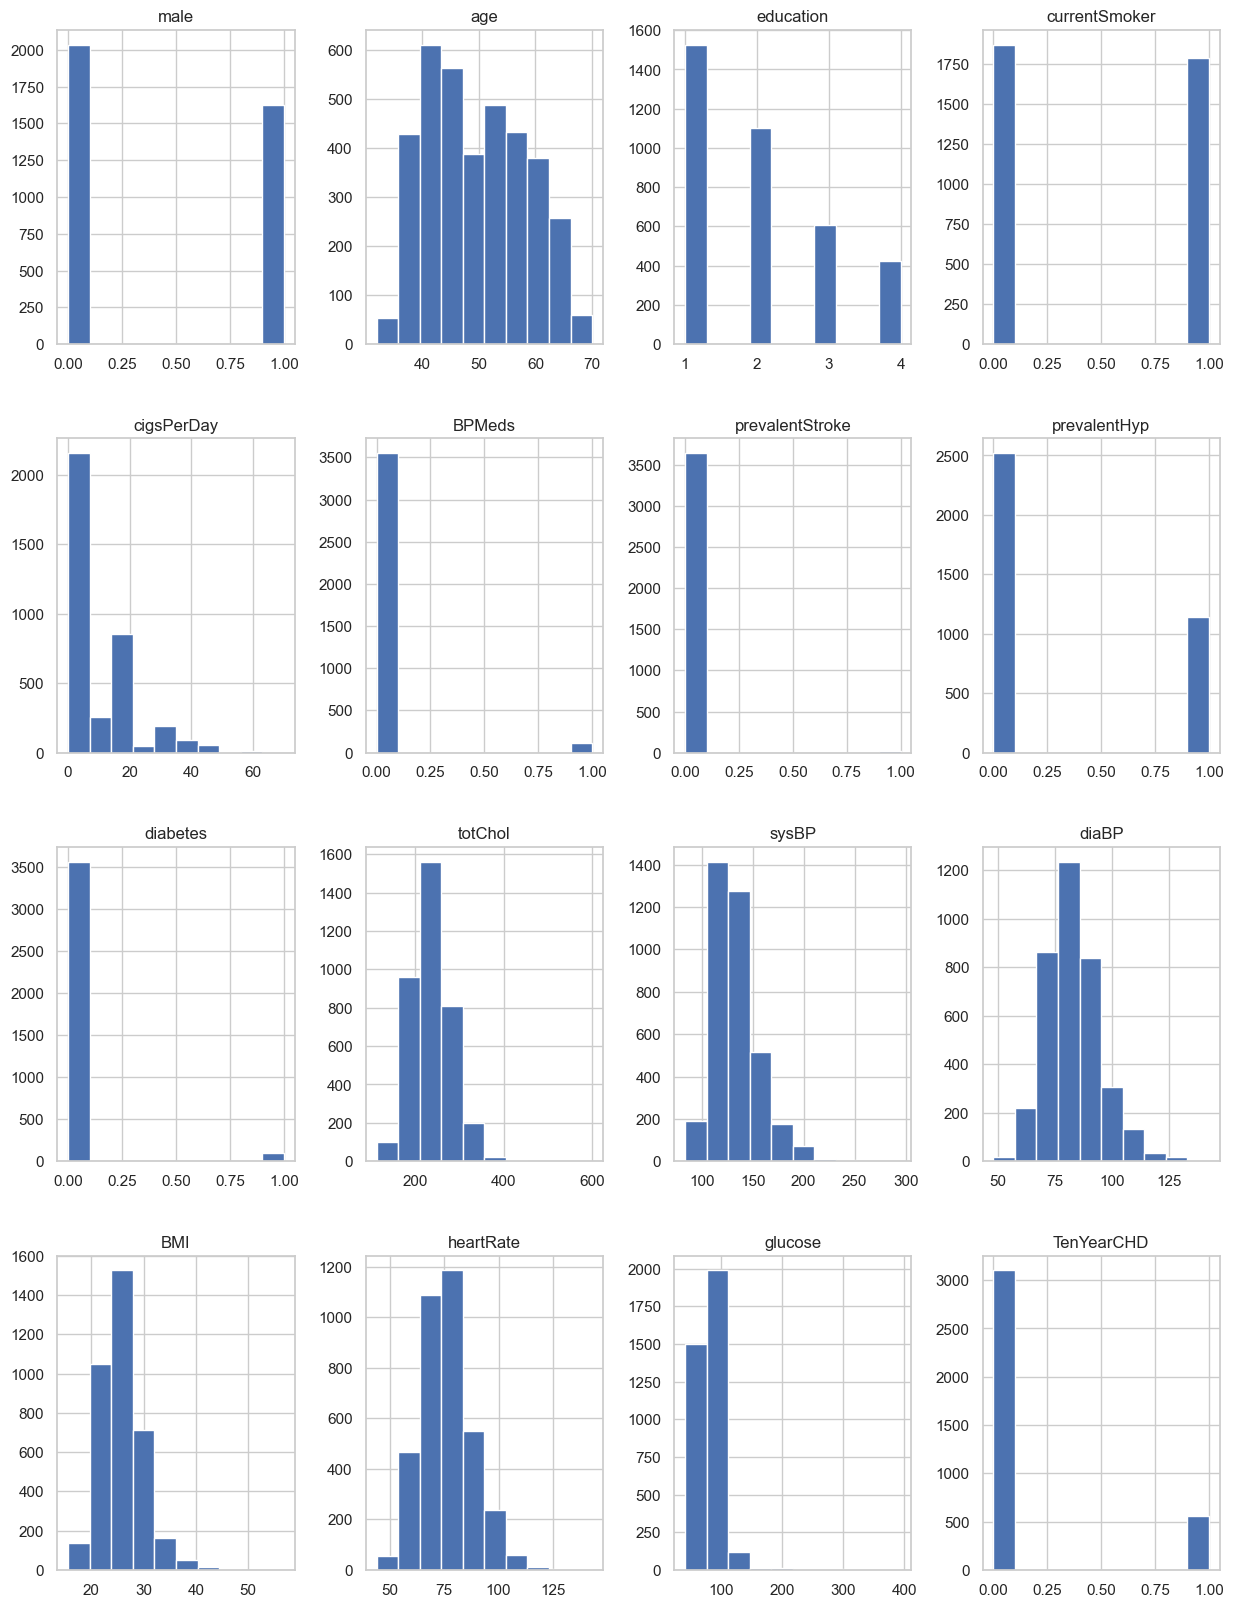

In [22]:
fig=plt.figure(figsize=(15,20))
ax =fig.gca()
df.hist(ax = ax)
plt.show()

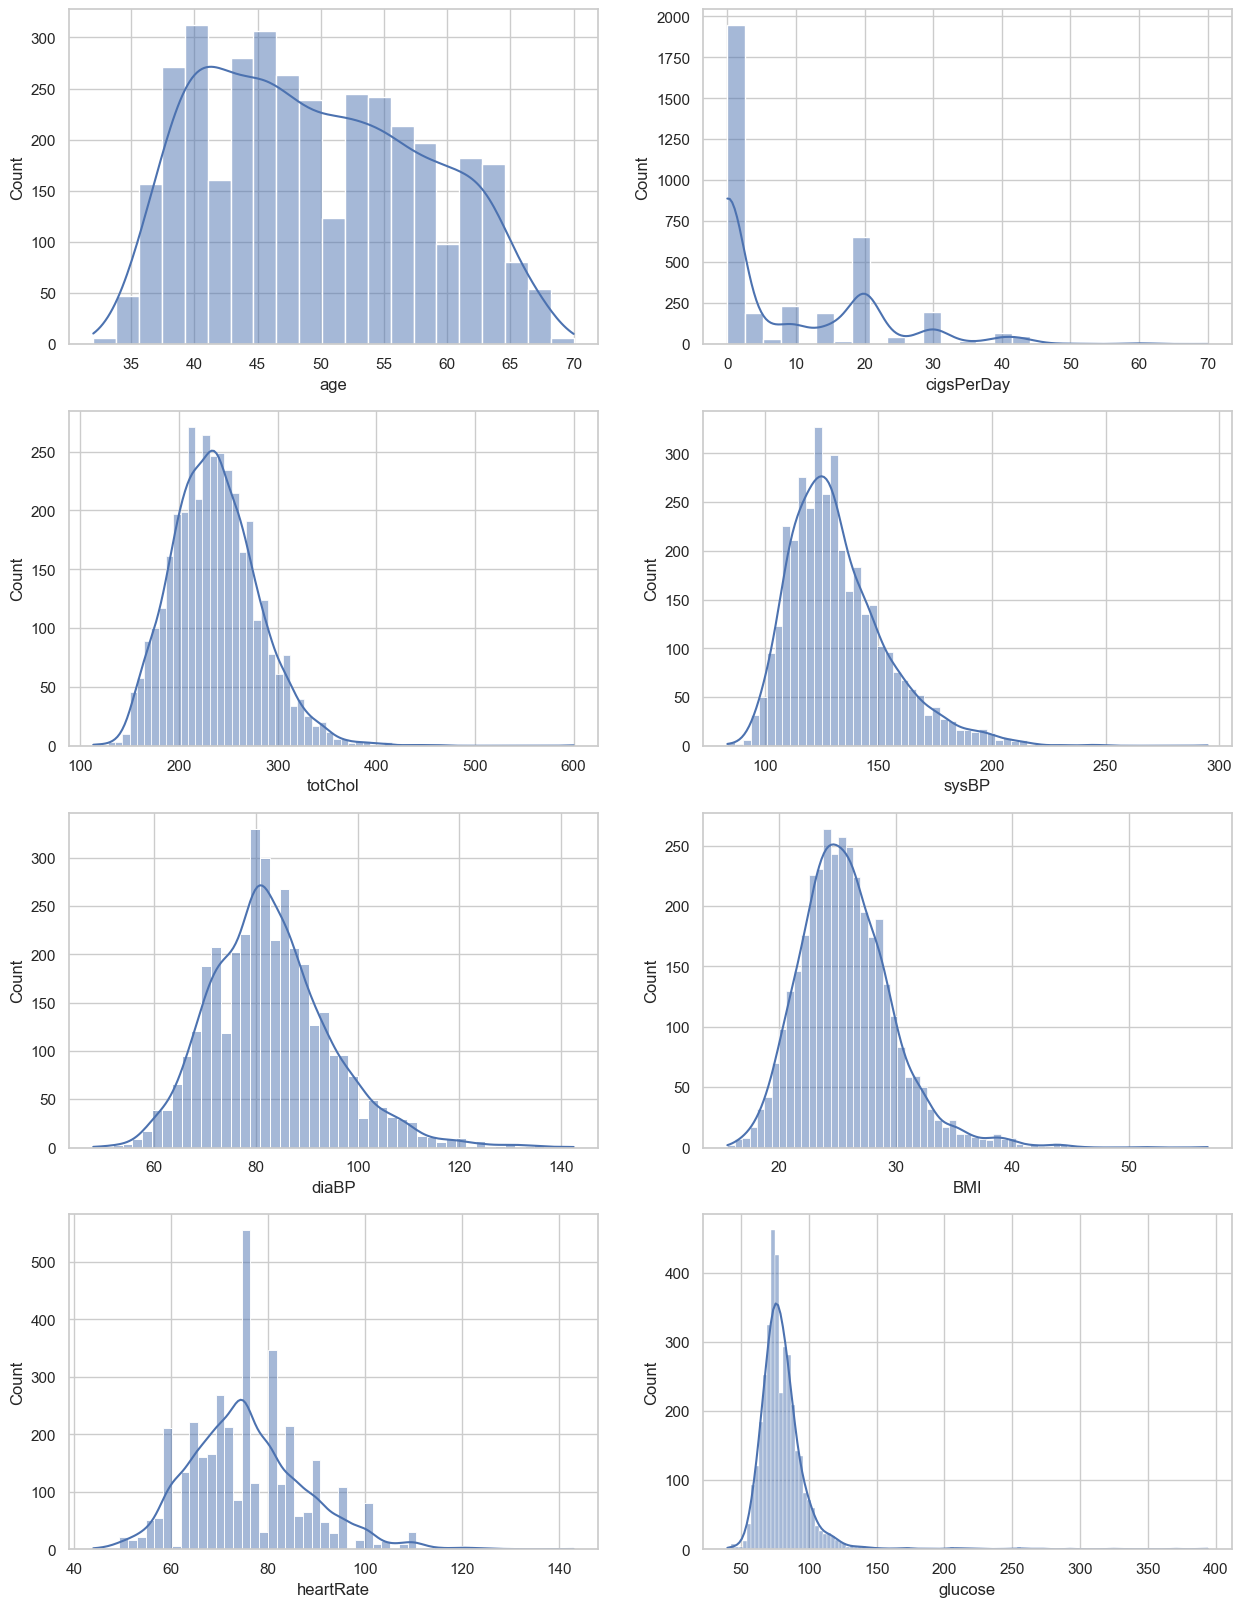

In [23]:
categorical_features = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
numeric_features = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
f, axes = plt.subplots(4, 2, figsize=(15,20))

index1 = 0
index2 = 0

for col in numeric_features:
    sns.histplot(df[col], ax=axes[index1][index2], kde=True)
    index2 = index2 + 1
    if index2 == 2:
        index2 = 0
        index1 = index1 + 1
plt.show()

As shown above, the variables totChol, sysBP, diaBP, BMI, and glucose all follow somewhat even distributions. cigsPerDay has an extremely uneven distribution, and heartRate has a moderately uneven distribution.

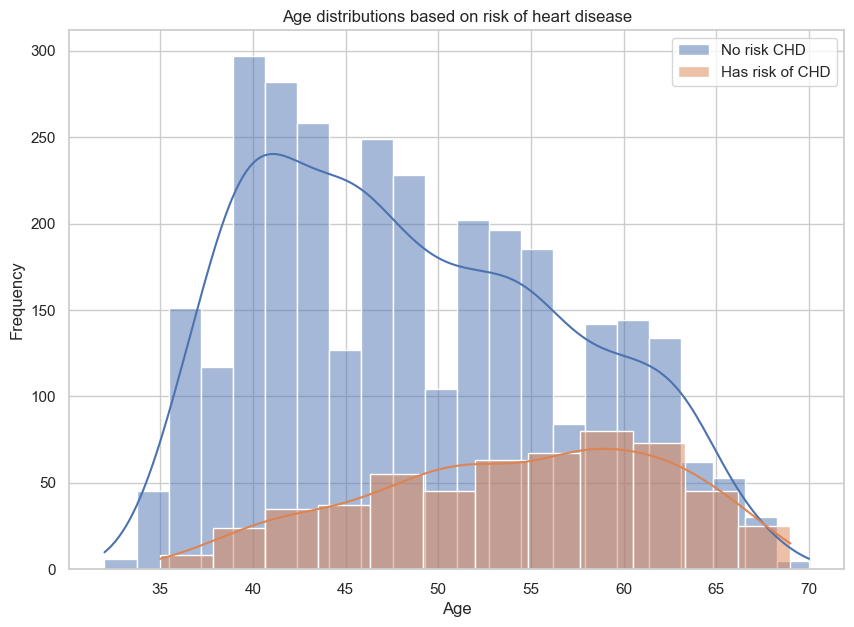

In [24]:
# 
plt.figure(figsize=(10, 7))
plt.title("Age distributions based on risk of heart disease")

sns.histplot(df[df['TenYearCHD']==0]['age'], label='No risk CHD', kde=True)
sns.histplot(df[df['TenYearCHD']==1]['age'], label='Has risk of CHD', kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()


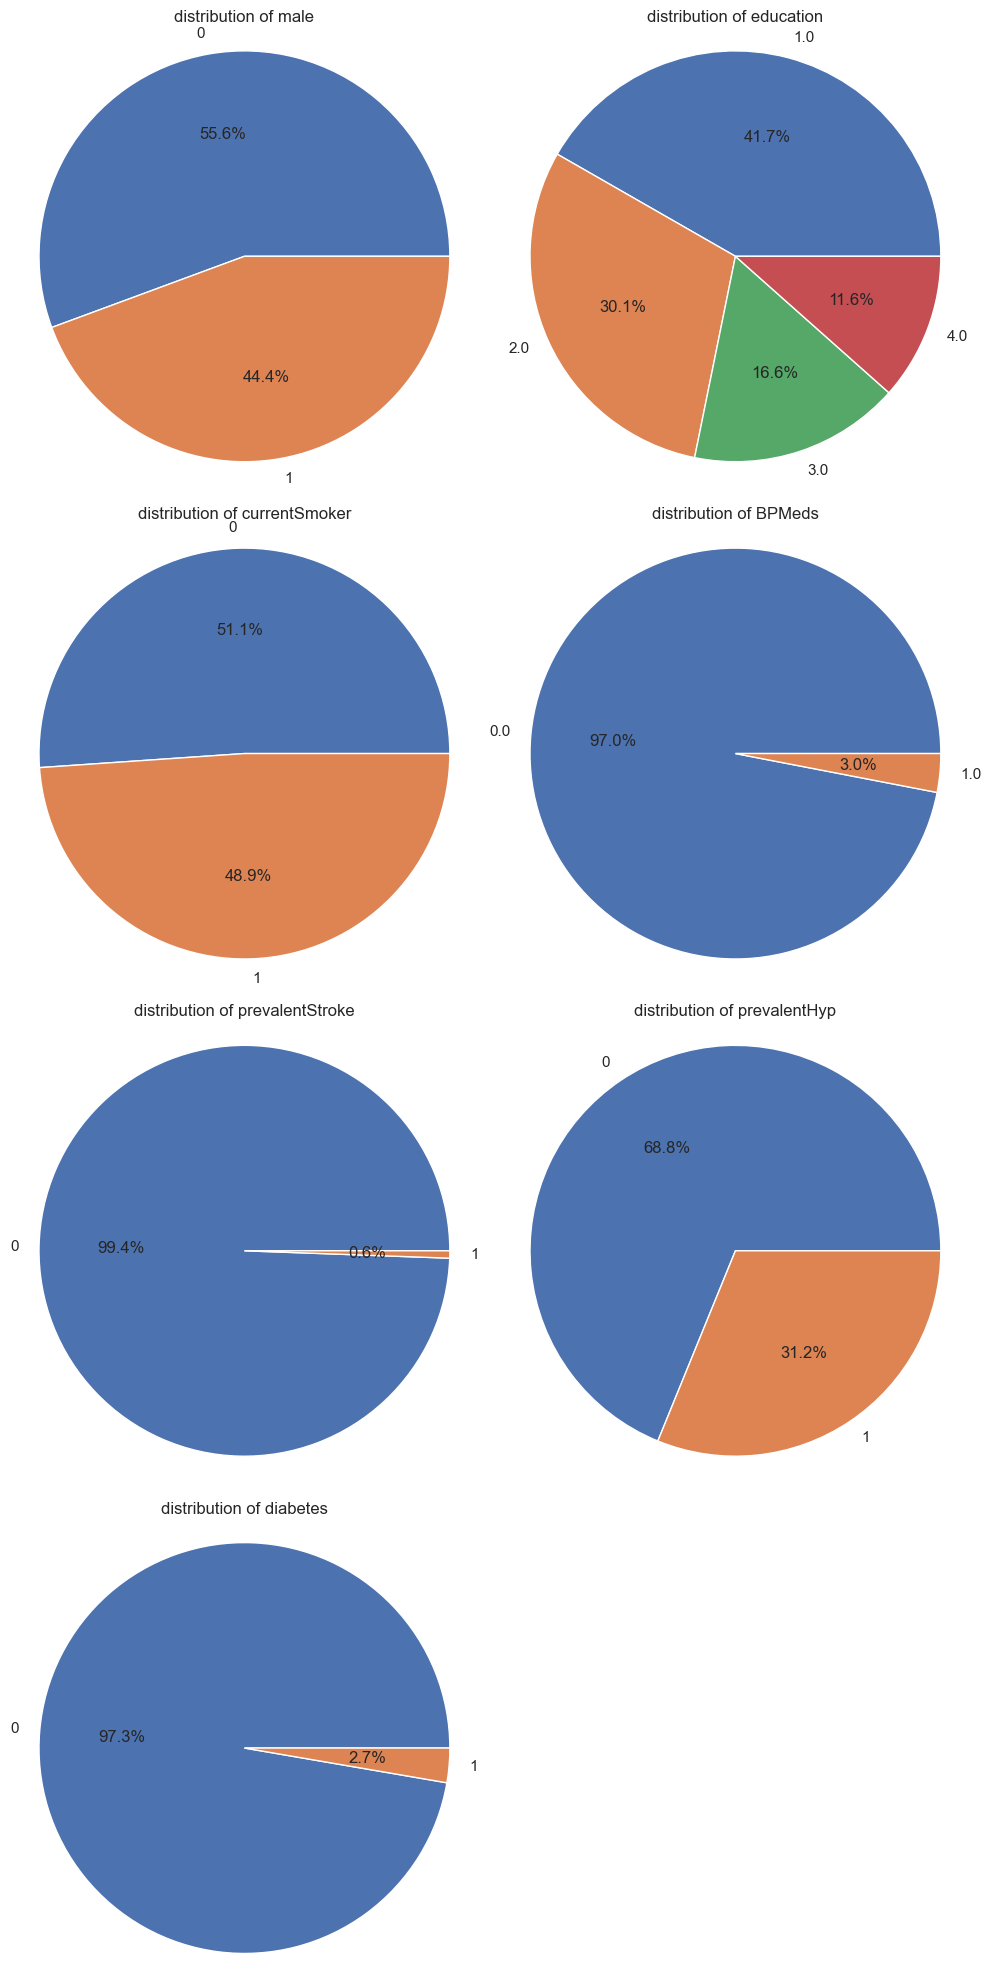

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    pie_data = df[col].value_counts()
    axes[i].pie(pie_data,
                labels=pie_data.index,
                autopct='%1.1f%%')
    axes[i].set_title(f"distribution of {col}")
    axes[i].axis('equal')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()



## Bivariate Analysis

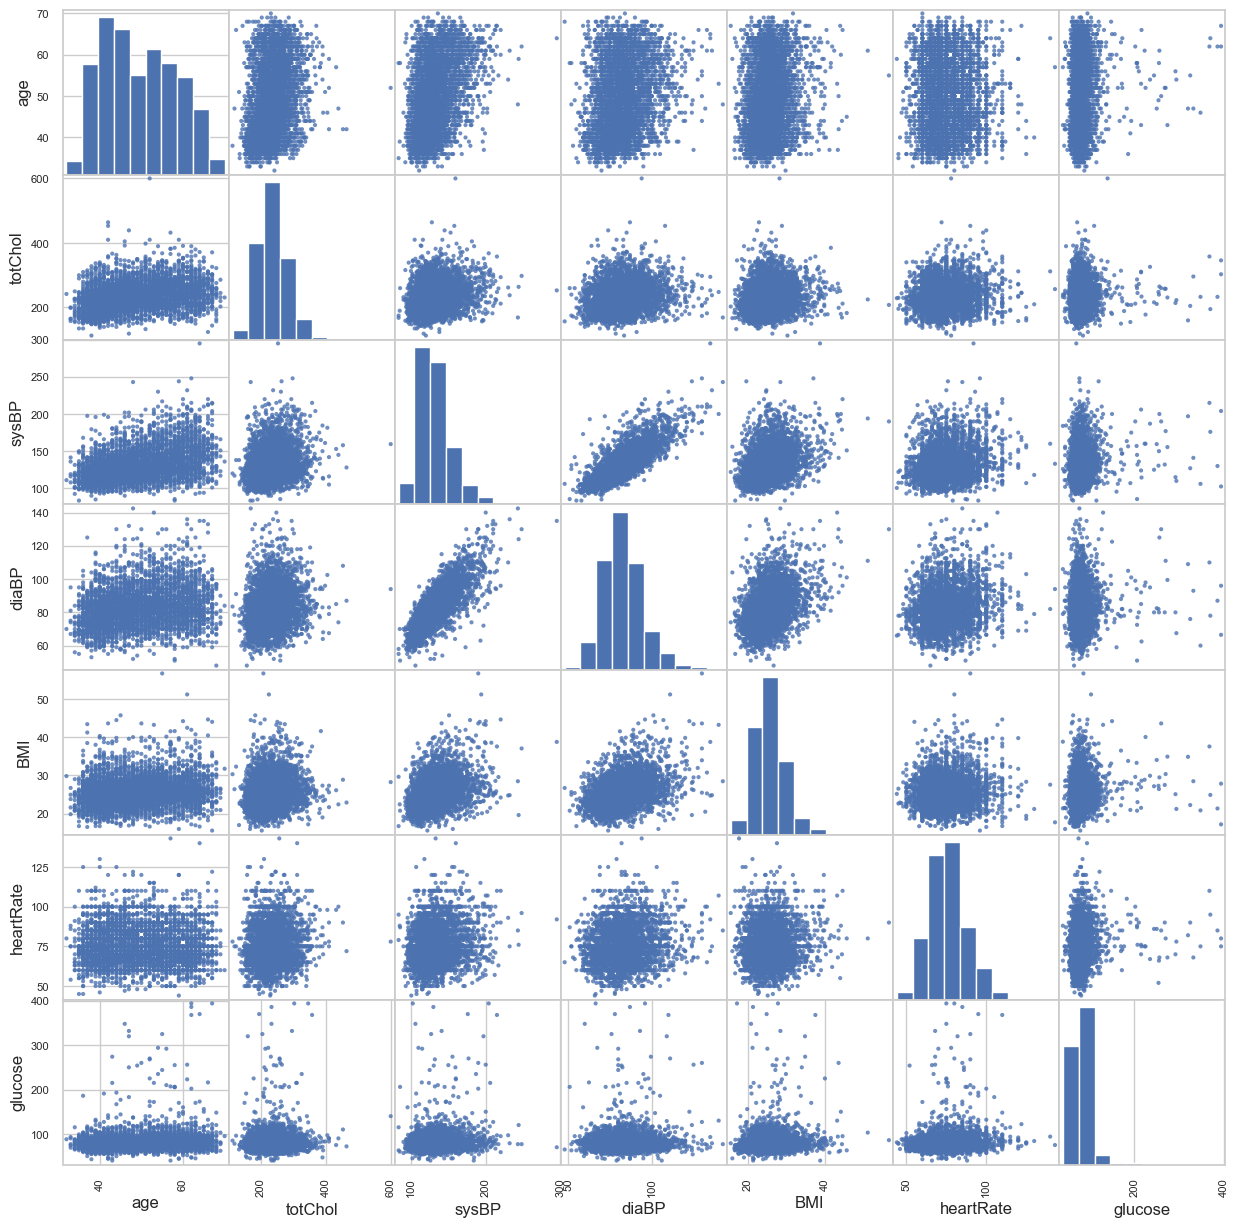

In [26]:
# scatterplots/pairplot to visualize relations of continuous variables of note

continuous_variables = ['age', 'totChol', 'sysBP', 'diaBP','BMI','heartRate','glucose']

pd.plotting.scatter_matrix(df[continuous_variables], alpha=0.8, figsize=(15,15), diagonal='hist')
plt.show()

observations of note:
- there is a strong positive relationship between sysBP and diaBP, which is to be expected.
- variables have visible horizontal/vertical banding due to rounded measurements
- several variables display large outliers such as glucose
- overall, apart from sysBP and diaBP, there are few strong pairwise correlations, suggesting multivariate models may capture interactions better than bivariate analysis
    

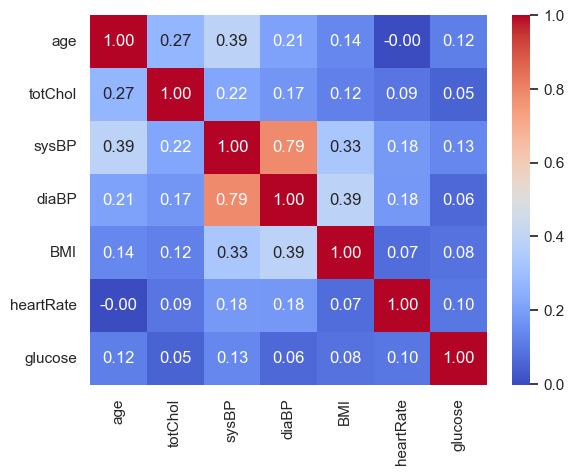

In [27]:
# correlation matrix
corr = df[continuous_variables].corr()

sns.heatmap(corr,  annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

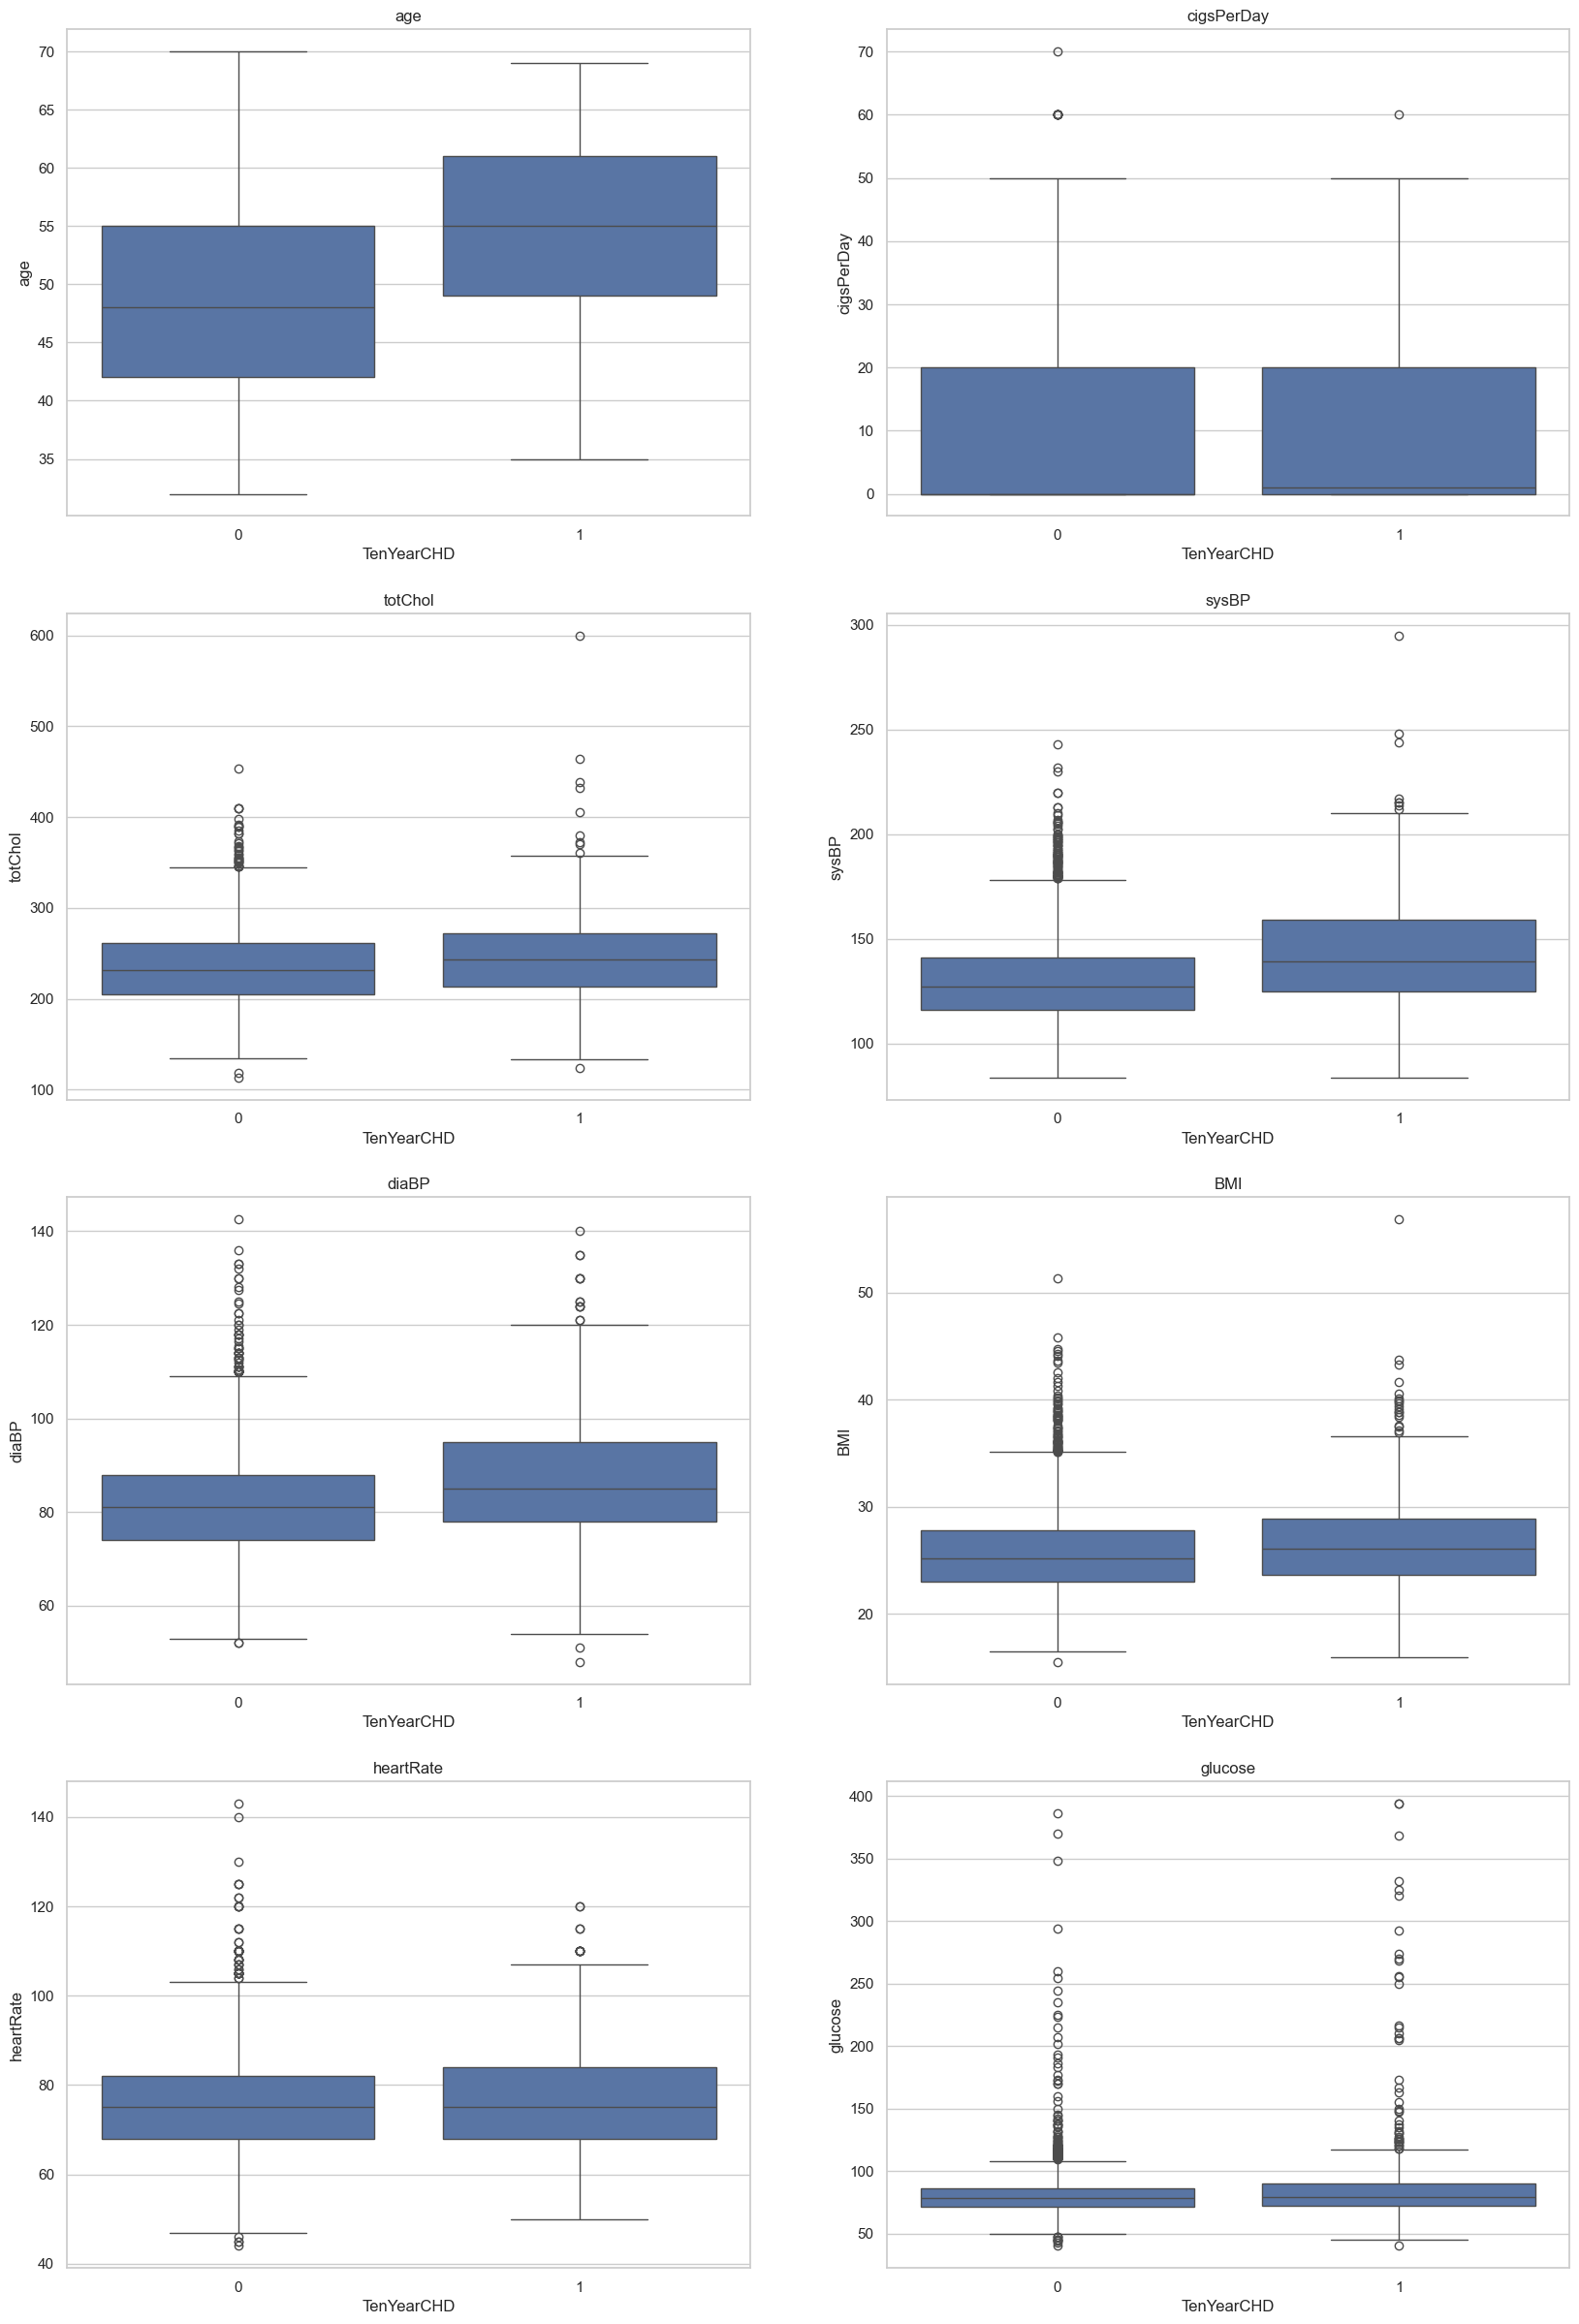

In [28]:
# box plots to see changes in distribution in relation to risk of CHD
plt.figure(figsize=(20,30))

for i, feature in enumerate(numeric_features):
    plt.subplot(4,2,i+1)
    sns.boxplot(x=df['TenYearCHD'], y=df[feature])
    plt.title(f"{feature}")

plt.show()

Observations of note:
- individuals with TenYearCHD tend to:
    - be older
    - have high blood pressure
    - slightly higher BMI
    - slightly higher cholesterol
- many variables contain numerous outliers
- no single feature perfectly separates CHD outcomes, indicating the usage of multivariate models to classify risk.

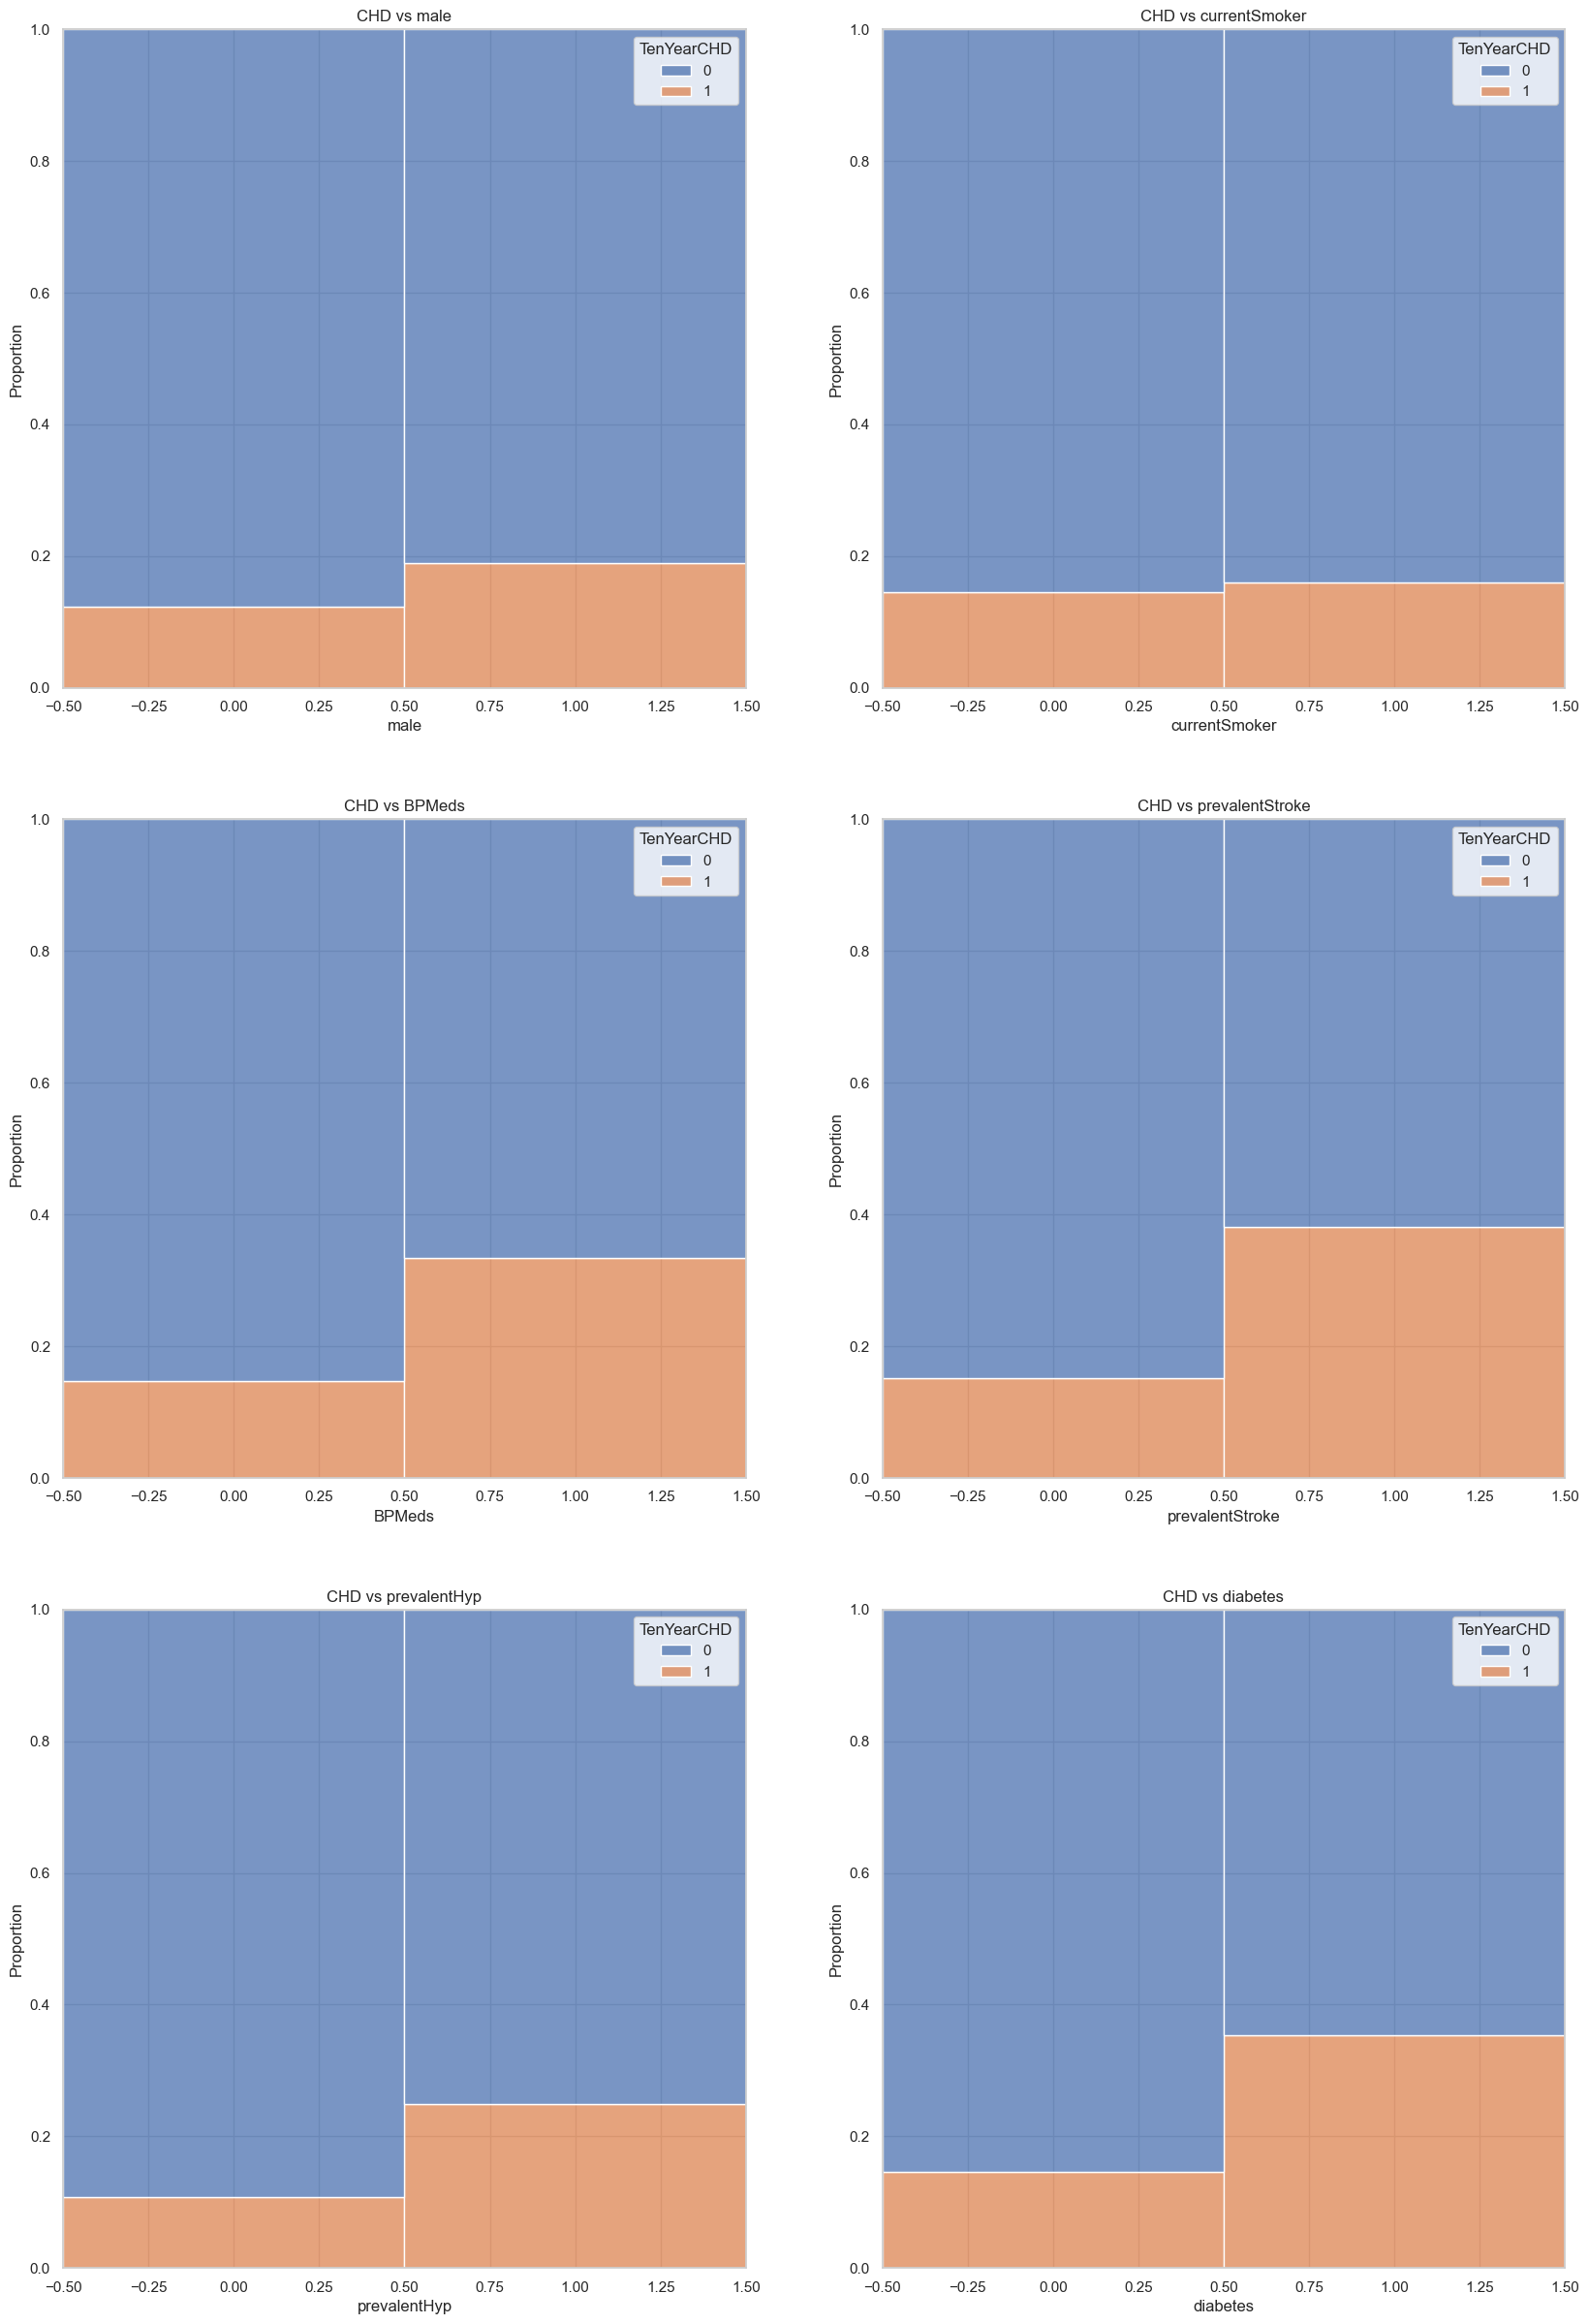

In [29]:
plt.figure(figsize=(20,30))

binary_features = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

for i, feature in enumerate(binary_features):
    plt.subplot(3,2,i+1)
    sns.histplot(df,
                 x=f"{feature}",
                 hue="TenYearCHD",
                 multiple="fill",
                 stat="proportion",
                 discrete=True)
    plt.title(f"CHD vs {feature}")

plt.show()

In [30]:
# Feature Selection by Chi Squared Testing

X = df[categorical_features]
y = df['TenYearCHD']

In [31]:
chi_scores = chi2(X, y)
chi_scores

(array([17.10775088,  7.73328653,  0.68647384, 28.19156867,  8.5078328 ,
        82.84545536, 31.06762071]),
 array([3.53178759e-05, 5.42119836e-03, 4.07366355e-01, 1.09882183e-07,
        3.53620967e-03, 8.87260079e-20, 2.49193807e-08]))

higher chi squared test values indicate higher importance of that particular feature in relation to the target variable(TenYearCHD). Thus we choose to include features with statistically siginificant stronger relationships with ten year risk of CHD.

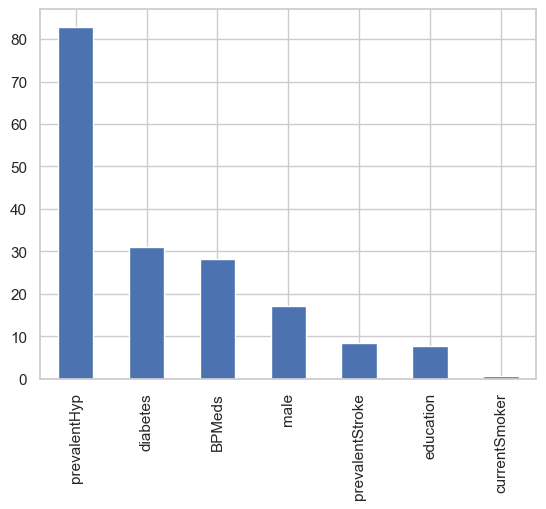

In [32]:
# higher chi squared test values indicate higher importance in relation to CHD risk
chi_values = pd.Series(chi_scores[0], index=X.columns)
chi_values.sort_values(ascending=False, inplace=True)
chi_values.plot.bar()
plt.show()

When using Chi Squared Feature selection, lower p-values indicate that there is a significant statistical relationship between the selected feature and the target variable, as in there is strong evidence of association between the two. In this project we consider results with p-values above 0.05 to be statistically insignificant, as we have insufficient evidence to support the null hypothesis that there is no significant difference between the categorical data's values and expected values.

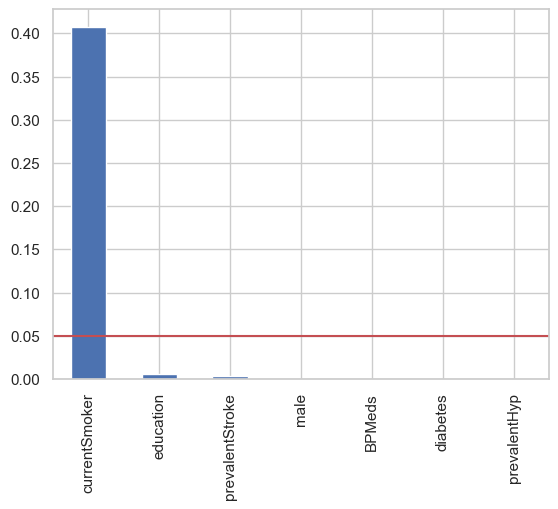

In [33]:
p_values = pd.Series(chi_scores[1], index=X.columns)
p_values.sort_values(ascending=False, inplace=True)
p_values.plot.bar()
plt.axhline(y=0.05, color='r', linestyle='-')
plt.show()

As shown, we can see that the feature currentSmoker has p-value greater than 0.05, therefore we will drop this feature as it is not statistically significant towards predicting ten year risk of CHD.

In [34]:
df_features = df.drop(['currentSmoker'], axis=1)
df_features.head()

,male,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Addressing class imbalances in the dataset
As shown previously, the dataset has a significant class imbalance favouring those not at risk of CHD. While this is representative of real life, training our models with such an imbalance may cause a classifier biased towards the no risk class. This would result in high overall accuracy but poor precision in regards to correctly identifying the minority class which is at risk.

To address this, we will balance the dataset using Synthetic Minority Over-Sampling Technique (SMOTE). This will reduce the imbalance by introducing new synthetic samples of the minority class, resulting in a more balanced distribution, improving performance in our primary objective of predicting ten year risk of CHD.

SMOTE follows the following procudure to introduce new synthetic samples:
1. randomly select an instance of the minority class
2. find its 'k' nearest neighbours among other minority class instances
3. of these k neighbours, it selects one random neighbour
4. a new sample is created by taking a random point in the line between the original random datapoint and the randomly selected neighbour
5. this process is repeated until the minority class is sufficiently increased

In addition to using SMOTE to increase the size of the minority class, we will also use random undersampling to reduce the number of samples in the majority class. Using both of these techniques, we are able to balance the class distribution.

In [35]:
from collections import Counter
X = df_features.iloc[:, 0:14]
y = df_features.iloc[:, 14]

In [36]:
X.head()

,male,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


In [37]:
y.head()

0    0
1    0
2    0
3    1
4    0
Name: TenYearCHD, dtype: int64

In [38]:
# numbers before SMOTE
num_before = dict(Counter(y))

# define and perform SMOTE pipeline
over=SMOTE(sampling_strategy=0.8)
under=RandomUnderSampler(sampling_strategy=0.8)
steps=[("o",over),("u",under)]
pipeline = Pipeline(steps=steps)

# transform dataset
X_smote,y_smote=pipeline.fit_resample(X,y)

# numbers after SMOTE
num_after=dict(Counter(y_smote))


In [39]:
print(num_before,num_after)

{0: 3101, 1: 557} {0: 3100, 1: 2480}


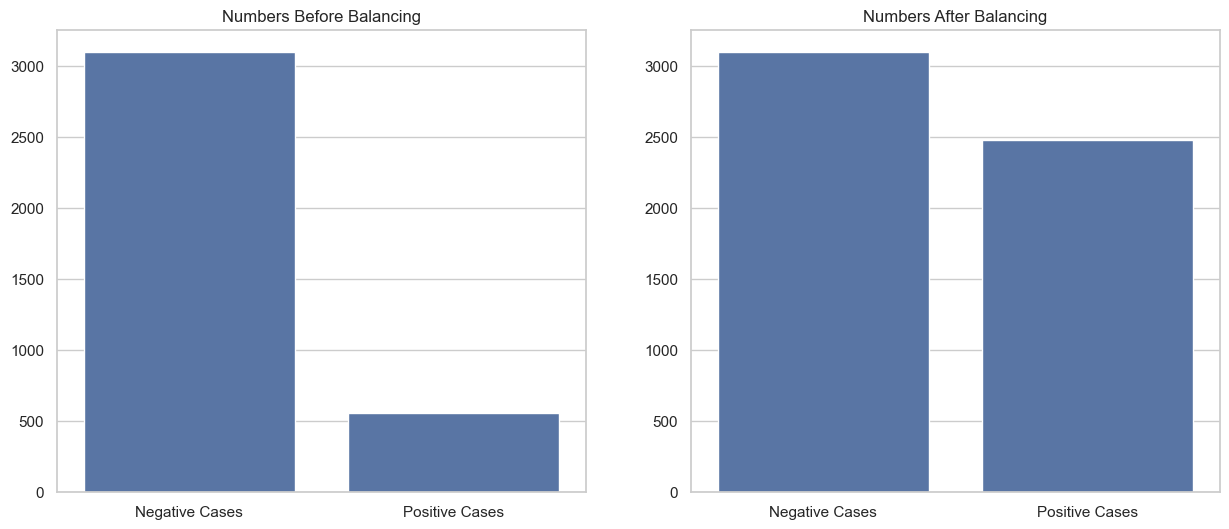

In [40]:
labels = ["Negative Cases","Positive Cases"]
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.barplot(x=labels, y=list(num_before.values()))
plt.title("Numbers Before Balancing")
plt.subplot(1,2,2)
sns.barplot(x=labels, y=list(num_after.values()))
plt.title("Numbers After Balancing")
plt.show()

## Train Test Splitting the Data

In [41]:
df_features.columns

Index(['male', 'age', 'education', 'cigsPerDay', 'BPMeds', 'prevalentStroke',
       'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI',
       'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

In [42]:
df_rebalanced = pd.concat([pd.DataFrame(X_smote), pd.DataFrame(y_smote)], axis=1)
df_rebalanced.head()

,male,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1767,1,40,1.0,3.0,0.0,0,0,0,165.0,117.0,77.0,21.71,50.0,66.0,0
2213,0,39,4.0,15.0,0.0,0,0,0,226.0,115.0,80.0,25.19,72.0,74.0,0
2817,0,66,3.0,20.0,0.0,0,0,0,241.0,112.0,66.0,23.36,75.0,74.0,0
3433,1,39,4.0,1.0,0.0,0,0,0,163.0,129.0,84.0,21.01,60.0,120.0,0
2252,1,64,1.0,0.0,0.0,0,1,0,188.0,191.0,106.0,37.38,82.0,84.0,0


In [43]:
# reformatting as dataframes
X_rebalanced = pd.DataFrame(X_smote)
y_rebalanced = pd.DataFrame(y_smote)
X_rebalanced.head()

,male,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
1767,1,40,1.0,3.0,0.0,0,0,0,165.0,117.0,77.0,21.71,50.0,66.0
2213,0,39,4.0,15.0,0.0,0,0,0,226.0,115.0,80.0,25.19,72.0,74.0
2817,0,66,3.0,20.0,0.0,0,0,0,241.0,112.0,66.0,23.36,75.0,74.0
3433,1,39,4.0,1.0,0.0,0,0,0,163.0,129.0,84.0,21.01,60.0,120.0
2252,1,64,1.0,0.0,0.0,0,1,0,188.0,191.0,106.0,37.38,82.0,84.0


In [44]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_rebalanced, 
                                                    y_rebalanced, 
                                                    test_size=0.2, 
                                                    random_state=2026)

## Feature Scaling
Feature scaling is a process used to transform features to be standardized on the same scale/range. It is done to prevent the models from overweighting features with larger numerical values, or slow down execution times. 

In [45]:
scaler = StandardScaler()

In [46]:
X_train = pd.DataFrame(scaler.fit_transform(X_train))
X_test = pd.DataFrame(scaler.transform(X_test))

## Models
The models to be used and compared in this project are:
1. K-Nearest Neighbours
2. Decision Trees
3. Support Vector Machine
4. Logistic Regression
5. Random Forest Classification
6. XGBoost

### Logistic Regression


In [47]:
# use gridsearch to find optimal parameters 
param_grid = {'penalty':['l1','l2'],
              'C':[0.01,0.1,1,10,100],
              'class_weight':['balanced', None]}

logistic_clf = GridSearchCV(LogisticRegression(), param_grid=param_grid, cv=10, scoring='roc_auc')

In [48]:
# fitting model
logistic_clf.fit(X_train,y_train)

logistic_clf.best_params_

{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}

In [49]:
# make prediction of test set
logistic_predict = logistic_clf.predict(X_test)

In [50]:
# measure accuracy
logistic_acc = accuracy_score(y_test, logistic_predict)
print(f"The logistic regression model yields an accuracy of {round(logistic_acc*100,2)}%")

The logistic regression model yields an accuracy of 69.0%


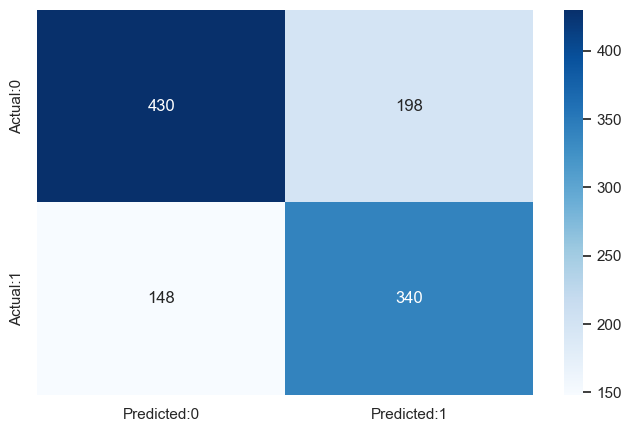

In [51]:
cm = confusion_matrix(y_test, logistic_predict)
conf_matrix=pd.DataFrame(data=cm,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True,fmt='d', cmap="Blues")
plt.show()

In [52]:
print(classification_report(y_test,logistic_predict))
logistic_f1 = f1_score(y_test, logistic_predict)
print(f'f1 score for logistic regression: {round(logistic_f1*100,2)}%')

              precision    recall  f1-score   support

           0       0.74      0.68      0.71       628
           1       0.63      0.70      0.66       488

    accuracy                           0.69      1116
   macro avg       0.69      0.69      0.69      1116
weighted avg       0.69      0.69      0.69      1116

f1 score for logistic regression: 66.28%


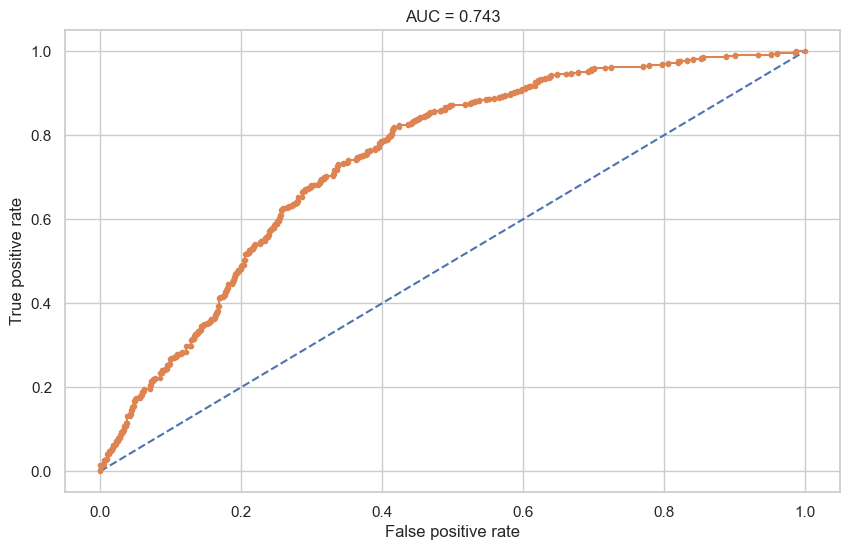

In [53]:
# AUC-ROC curve
probs = logistic_clf.predict_proba(X_test)
# preserve only probabilities for at risk
probs = probs[:, 1]

logistic_auc = roc_auc_score(y_test, probs)
logistic_fpr, logistic_tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(10,6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(logistic_fpr, logistic_tpr, marker='.')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.title(f"AUC = {round(logistic_auc,3)}")
plt.show()


### K-Nearest Neighbours (KNN)

In [54]:
# use gridsearch to find optimal parameters 
param_grid = {'n_neighbors': np.arange(1, 10)}
knn_clf = GridSearchCV(estimator=KNeighborsClassifier(), 
                           param_grid=param_grid, 
                           scoring='accuracy',  
                           cv=10,
                           n_jobs=-2)

In [55]:
# fitting model
knn_clf.fit(X_train,y_train)
knn_clf.best_params_

{'n_neighbors': np.int64(1)}

In [56]:
# make prediction of test set
knn_predict = knn_clf.predict(X_test)

In [57]:
# measure accuracy
knn_acc = accuracy_score(y_test, knn_predict)
print(f"The KNN model yields an accuracy of {round(knn_acc*100,2)}%")

The KNN model yields an accuracy of 82.08%


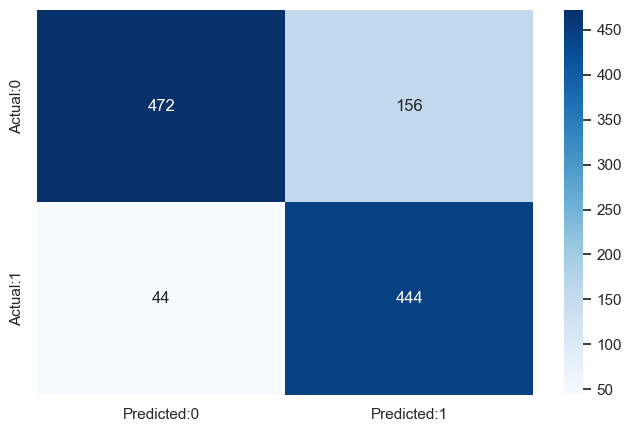

In [58]:
cm = confusion_matrix(y_test, knn_predict)
conf_matrix=pd.DataFrame(data=cm,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.show()

In [59]:
print(classification_report(y_test,knn_predict))
knn_f1 = f1_score(y_test, knn_predict)
print(f'f1 score for KNN: {round(knn_f1*100,2)}%')

              precision    recall  f1-score   support

           0       0.91      0.75      0.83       628
           1       0.74      0.91      0.82       488

    accuracy                           0.82      1116
   macro avg       0.83      0.83      0.82      1116
weighted avg       0.84      0.82      0.82      1116

f1 score for KNN: 81.62%


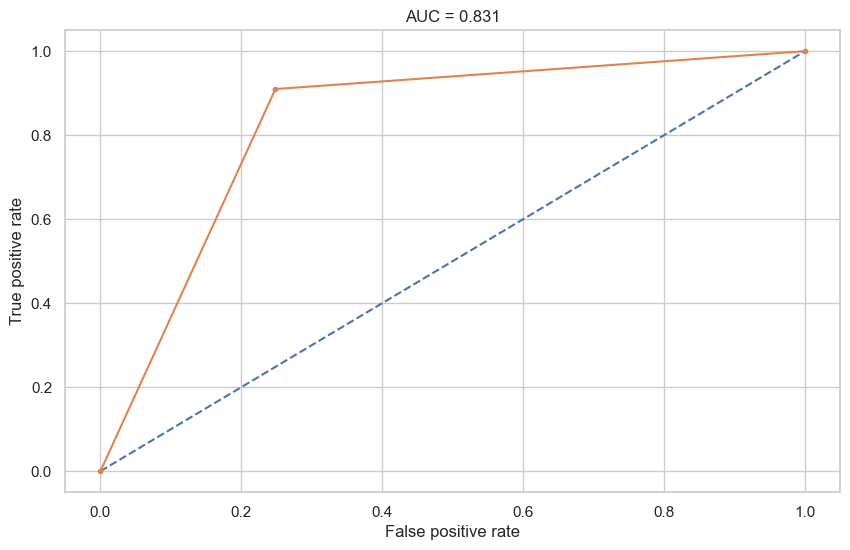

In [60]:
# AUC-ROC curve
probs = knn_clf.predict_proba(X_test)
# preserve only probabilities for at risk
probs = probs[:, 1]

knn_auc = roc_auc_score(y_test, probs)
knn_fpr, knn_tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(10,6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(knn_fpr, knn_tpr, marker='.')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.title(f"AUC = {round(knn_auc,3)}")
plt.show()

### Decision Trees

In [61]:
dtree = DecisionTreeClassifier(random_state=2026)

#
param_grid = {'max_features': [ 'sqrt', 'log2'],
          'min_samples_split': [2,3,4,5,6,7,8,9,10,11,12,13,14,15],
          'min_samples_leaf':[1,2,3,4,5,6,7,8,9,10,11]}
tree_clf = GridSearchCV(dtree, param_grid=param_grid, n_jobs=-2)

In [62]:
#
tree_clf.fit(X_train,y_train)
tree_clf.best_params_

{'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4}

In [63]:
#
tree_predict = tree_clf.predict(X_test)

In [64]:
# measure accuracy
tree_acc = accuracy_score(y_test, tree_predict)
print(f"The decision tree model yields an accuracy of {round(tree_acc*100,2)}%")

The decision tree model yields an accuracy of 77.42%


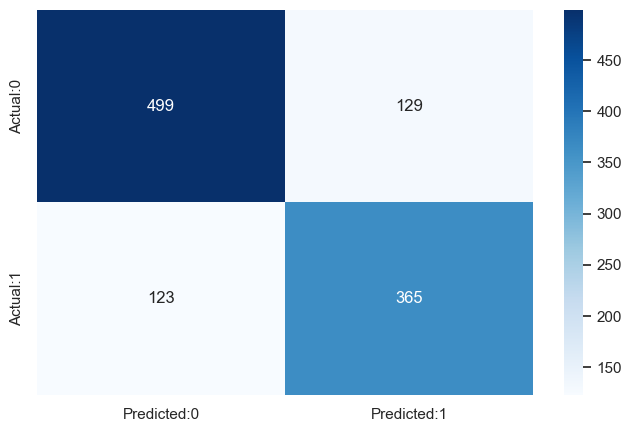

In [65]:
cm = confusion_matrix(y_test, tree_predict)
conf_matrix=pd.DataFrame(data=cm,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.show()

In [66]:
print(classification_report(y_test,tree_predict))
tree_f1 = f1_score(y_test, tree_predict)
print(f'f1 score for Decision Trees: {round(tree_f1*100,2)}%')

              precision    recall  f1-score   support

           0       0.80      0.79      0.80       628
           1       0.74      0.75      0.74       488

    accuracy                           0.77      1116
   macro avg       0.77      0.77      0.77      1116
weighted avg       0.77      0.77      0.77      1116

f1 score for Decision Trees: 74.34%


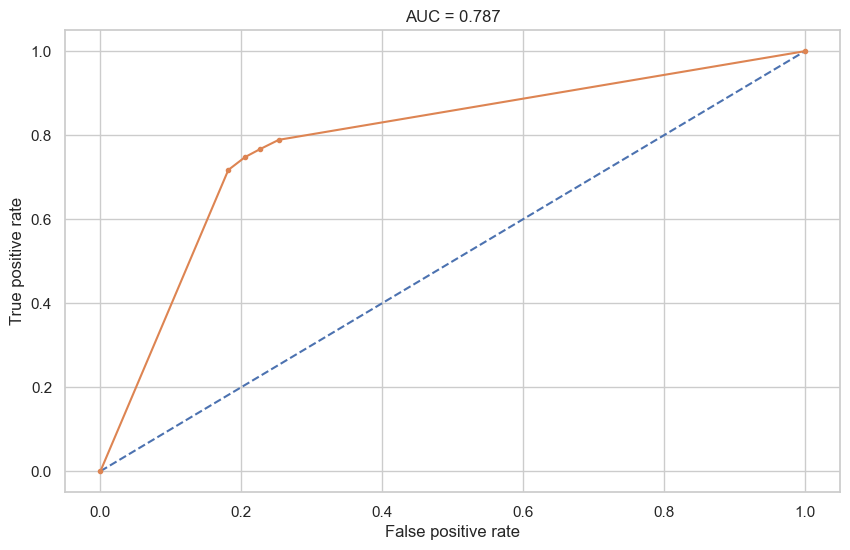

In [67]:
# AUC-ROC curve
probs = tree_clf.predict_proba(X_test)
# preserve only probabilities for at risk
probs = probs[:, 1]

tree_auc = roc_auc_score(y_test, probs)
tree_fpr, tree_tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(10,6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(tree_fpr, tree_tpr, marker='.')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.title(f"AUC = {round(tree_auc,3)}")
plt.show()

### Support Vector Machines (SVM)

In [68]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10],
               'gamma' : [0.001, 0.01, 0.1, 1]}
svm_clf = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=10, n_jobs=-2)

In [69]:
svm_clf.fit(X_train,y_train)
svm_clf.best_params_

{'C': 10, 'gamma': 1}

In [70]:
svm_predict = svm_clf.predict(X_test)

In [71]:
# measure accuracy
svm_acc = accuracy_score(y_test, svm_predict)
print(f"The SVM model yields an accuracy of {round(svm_acc*100,2)}%")

The SVM model yields an accuracy of 86.83%


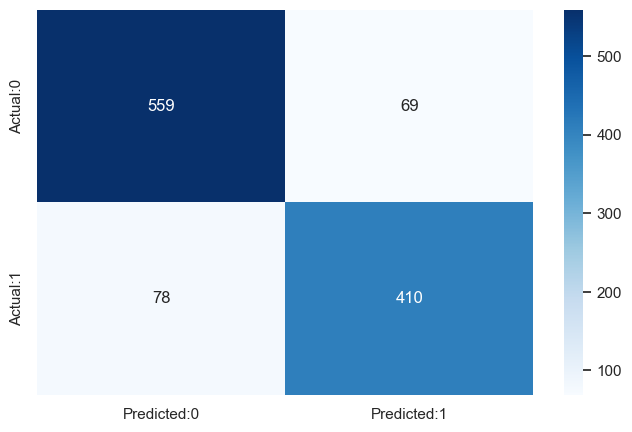

In [72]:
cm = confusion_matrix(y_test, svm_predict)
conf_matrix=pd.DataFrame(data=cm,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.show()

In [73]:
print(classification_report(y_test,svm_predict))
svm_f1 = f1_score(y_test, svm_predict)
print(f'f1 score for SVM: {round(svm_f1*100,2)}%')

              precision    recall  f1-score   support

           0       0.88      0.89      0.88       628
           1       0.86      0.84      0.85       488

    accuracy                           0.87      1116
   macro avg       0.87      0.87      0.87      1116
weighted avg       0.87      0.87      0.87      1116

f1 score for SVM: 84.8%


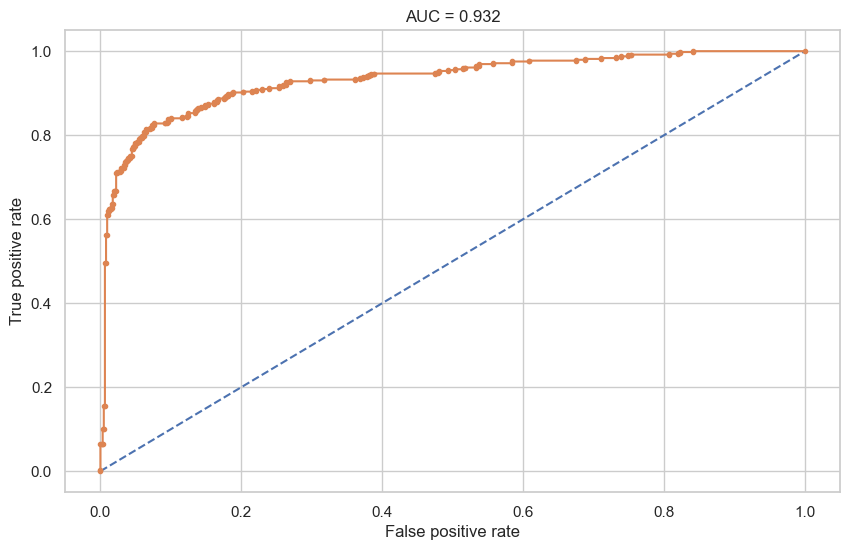

In [74]:
# AUC-ROC curve
probs = svm_clf.predict_proba(X_test)
# preserve only probabilities for at risk
probs = probs[:, 1]

svm_auc = roc_auc_score(y_test, probs)
svm_fpr, svm_tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(10,6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(svm_fpr, svm_tpr, marker='.')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.title(f"AUC = {round(svm_auc,3)}")
plt.show()

### Random Forest Classification

In [75]:
rf_classifier = RandomForestClassifier(random_state=2026)

In [76]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}

In [77]:
rf_clf = GridSearchCV(rf_classifier, param_grid, cv=5, n_jobs=-2)
rf_clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...om_state=2026)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [78]:
rf_clf.best_params_

{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [79]:
rf_predict = rf_clf.predict(X_test)

In [80]:
# measure accuracy
rf_acc = accuracy_score(y_test, rf_predict)
print(f"The Random Forest model yields an accuracy of {round(rf_acc*100,2)}%")

The Random Forest model yields an accuracy of 87.54%


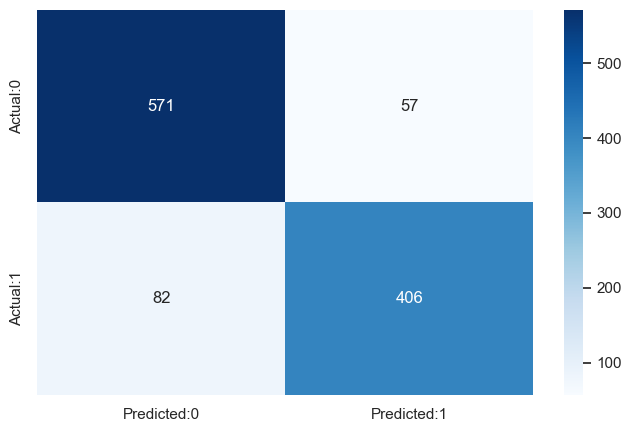

In [81]:
cm = confusion_matrix(y_test, rf_predict)
conf_matrix=pd.DataFrame(data=cm,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.show()

In [82]:
print(classification_report(y_test,rf_predict))
rf_f1 = f1_score(y_test, rf_predict)
print(f'f1 score for Random Forest: {round(rf_f1*100,2)}%')

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       628
           1       0.88      0.83      0.85       488

    accuracy                           0.88      1116
   macro avg       0.88      0.87      0.87      1116
weighted avg       0.88      0.88      0.88      1116

f1 score for Random Forest: 85.38%


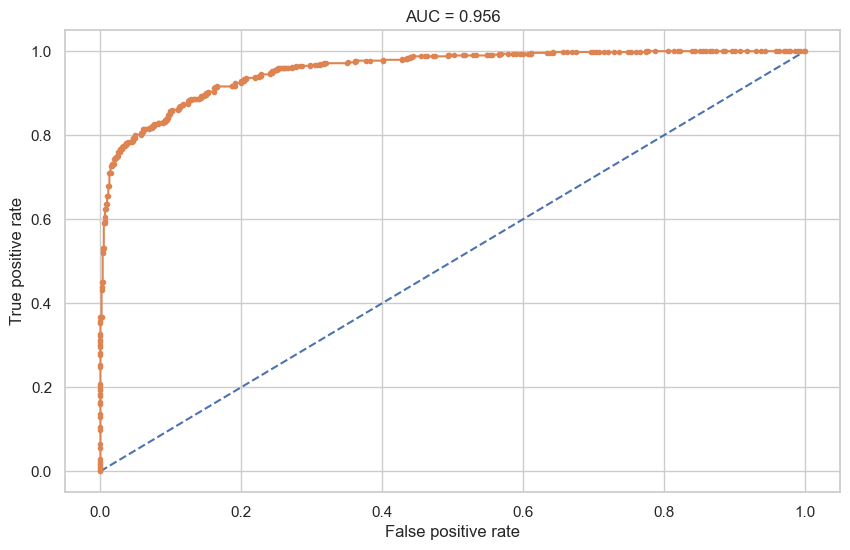

In [83]:
# AUC-ROC curve
probs = rf_clf.predict_proba(X_test)
# preserve only probabilities for at risk
probs = probs[:, 1]

rf_auc = roc_auc_score(y_test, probs)
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(10,6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(rf_fpr, rf_tpr, marker='.')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.title(f"AUC = {round(rf_auc,3)}")
plt.show()

### eXtreme Gradient Boosting (XGBoost)

In [84]:
xgb = XGBClassifier(objective="binary:logistic",
                    eval_metric="auc",
                    random_state=2026
                    )

In [85]:
param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7]
}

In [86]:
xgb_clf = GridSearchCV(estimator=xgb, 
                       param_grid=param_grid,
                       scoring="roc_auc",
                       cv=5,
                       n_jobs=-1
                       )

In [87]:
xgb_clf.fit(X_train, y_train)
xgb_clf.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.05,
 'max_depth': 7,
 'min_child_weight': 1,
 'n_estimators': 500,
 'subsample': 0.8}

In [88]:
xgb_predict = xgb_clf.predict(X_test)

In [89]:
# measure accuracy
xgb_acc = accuracy_score(y_test, xgb_predict)
print(f"The XGBoost model yields an accuracy of {round(xgb_acc*100,2)}%")

The XGBoost model yields an accuracy of 87.54%


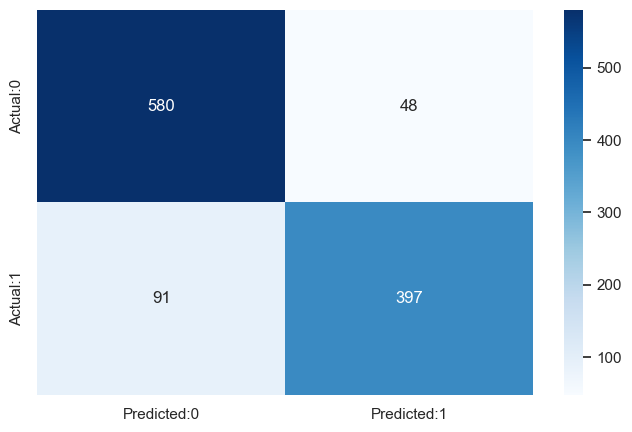

In [90]:
cm = confusion_matrix(y_test, xgb_predict)
conf_matrix=pd.DataFrame(data=cm,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.show()

In [91]:
print(classification_report(y_test,xgb_predict))
xgb_f1 = f1_score(y_test, xgb_predict)
print(f'f1 score for XGBoost: {round(xgb_f1*100,2)}%')

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       628
           1       0.89      0.81      0.85       488

    accuracy                           0.88      1116
   macro avg       0.88      0.87      0.87      1116
weighted avg       0.88      0.88      0.87      1116

f1 score for XGBoost: 85.1%


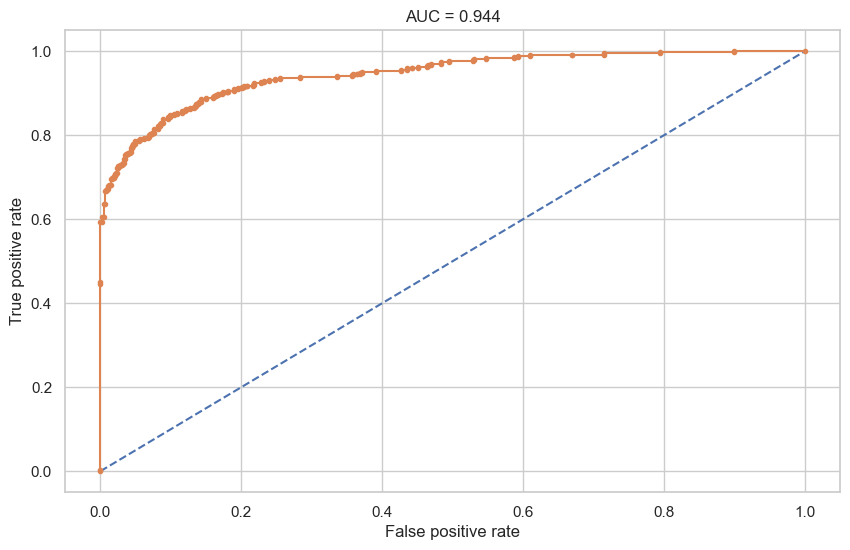

In [92]:
# AUC-ROC curve
probs = xgb_clf.predict_proba(X_test)
# preserve only probabilities for at risk
probs = probs[:, 1]

xgb_auc = roc_auc_score(y_test, probs)
xgb_fpr, xgb_tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(10,6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(xgb_fpr, xgb_tpr, marker='.')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.title(f"AUC = {round(xgb_auc,3)}")
plt.show()

## Model Comparison

In [93]:
reports={}

reports['Logistic Reg'] = classification_report(y_test, logistic_predict, output_dict=True)
reports['KNN'] = classification_report(y_test, knn_predict, output_dict=True)
reports['Decision Tree'] = classification_report(y_test, tree_predict, output_dict=True)
reports['SVM'] = classification_report(y_test, svm_predict, output_dict=True)
reports['Random Forest'] = classification_report(y_test, rf_predict, output_dict=True)
reports['XGBoost'] = classification_report(y_test, xgb_predict, output_dict=True)

rows=[]

for model_name, report in reports.items():
    rows.append({
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'F1 Score': report['1']['f1-score'],
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall']
    })

auc_scores = pd.Series({'Logistic Reg': logistic_auc, 
                        'KNN': knn_auc, 
                        'Decision Tree': tree_auc,
                        'SVM': svm_auc,
                        'Random Forest': rf_auc,
                        'XGBoost': xgb_auc
                        })

comparison_df = pd.DataFrame(rows)
comparison_df['AUC'] = comparison_df['Model'].map(auc_scores)

comparison_df

,Model,Accuracy,F1 Score,Precision,Recall,AUC
0,Logistic Reg,0.689964,0.662768,0.631970,0.696721,0.742998
1,KNN,0.820789,0.816176,0.740000,0.909836,0.830714
2,Decision Tree,0.774194,0.743381,0.738866,0.747951,0.787322
3,SVM,0.868280,0.847983,0.855950,0.840164,0.931834
4,Random Forest,0.875448,0.853838,0.876890,0.831967,0.956119
5,XGBoost,0.875448,0.851018,0.892135,0.813525,0.944470


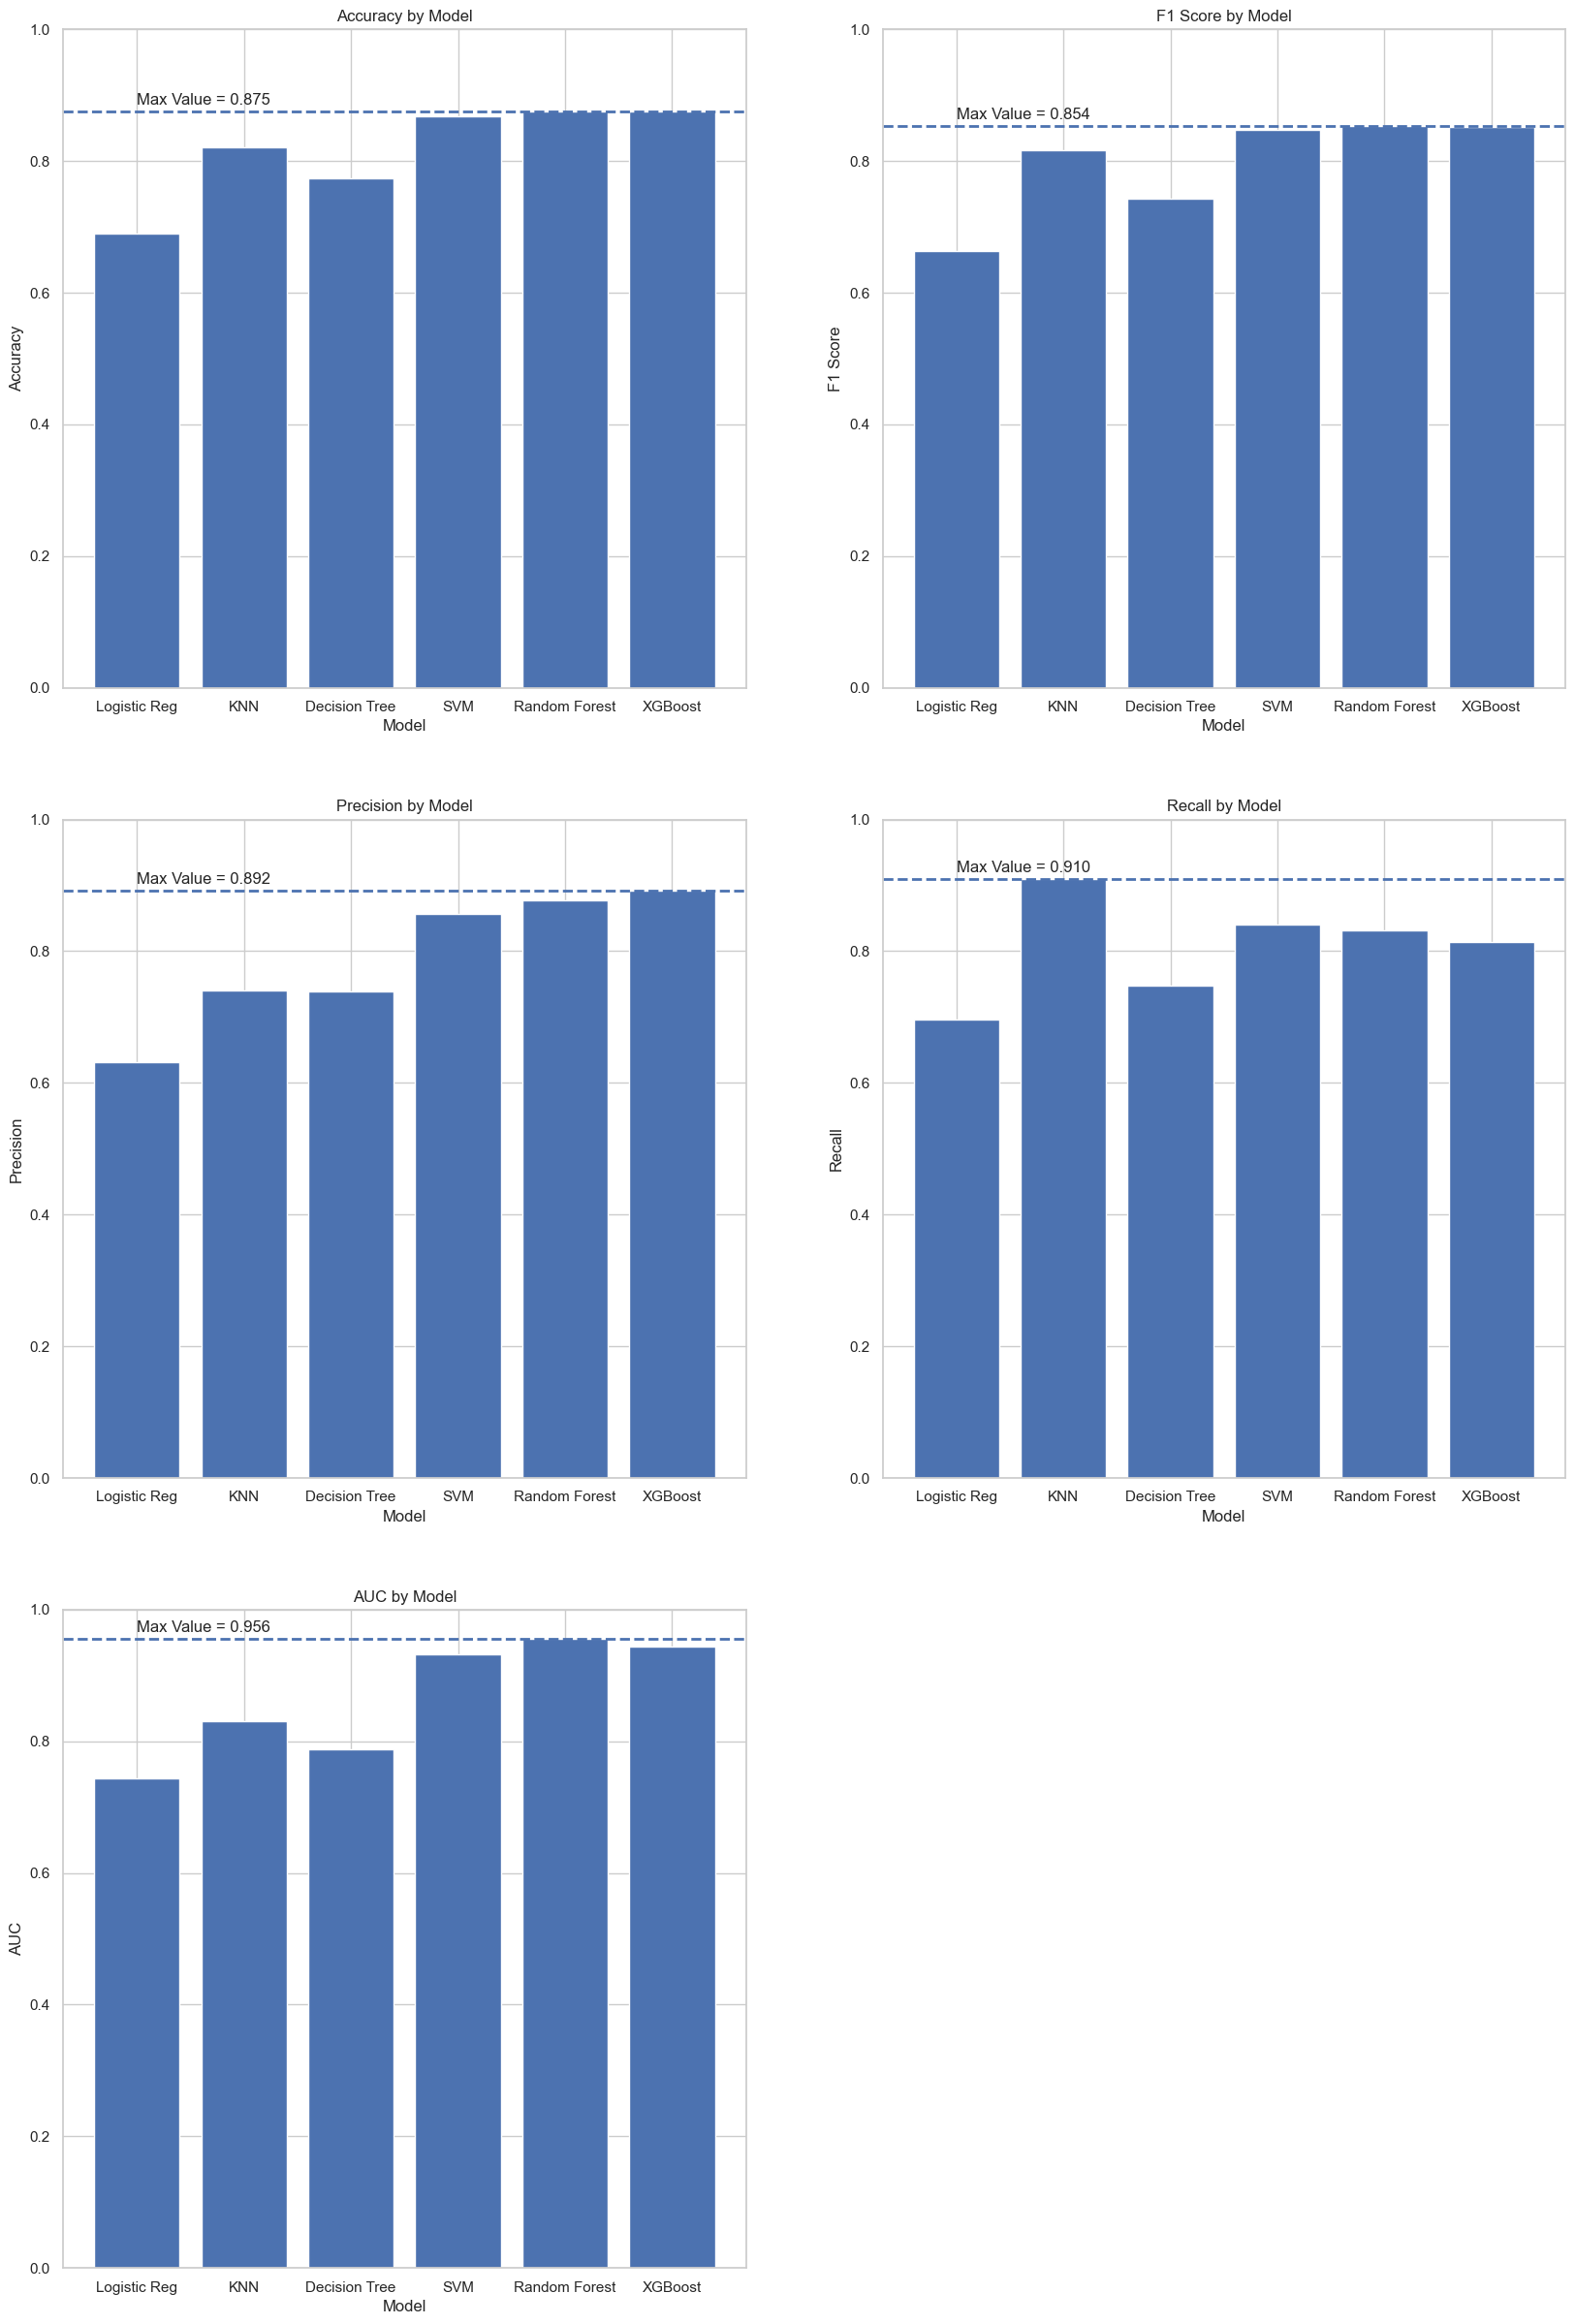

In [94]:
plt.figure(figsize=(20,30))

metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'AUC']

for i, metric in enumerate(metrics):
    plt.subplot(3,2,i+1)
    plt.bar(comparison_df['Model'], comparison_df[metric])
    max = comparison_df[metric].max()
    plt.axhline(
        y=max,
        linestyle='--',
        linewidth=2
    )
    plt.text(x=0, y=max + 0.01, s=f'Max Value = {max:.3f}'
)
    plt.title(f'{metric} by Model')
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.ylim(0, 1) 

plt.show()

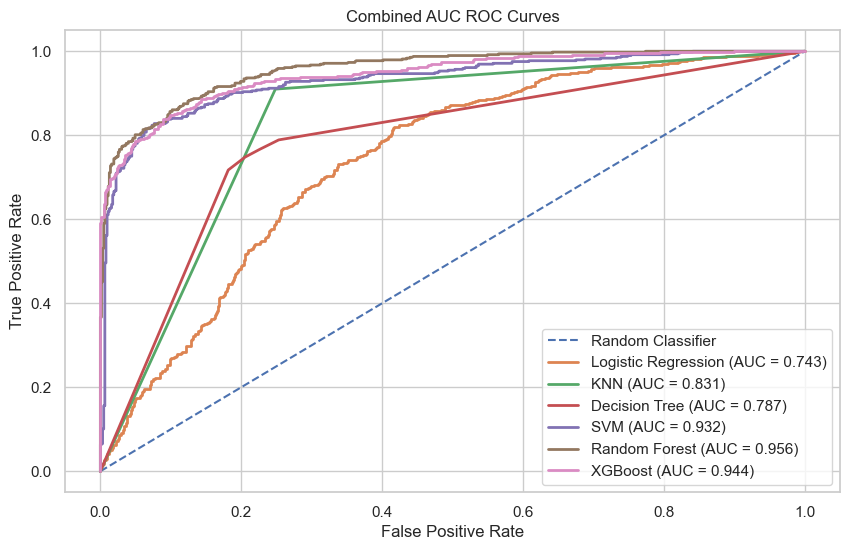

In [95]:
plt.figure(figsize=(10,6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.plot(logistic_fpr, logistic_tpr, linewidth=2, label=f'Logistic Regression (AUC = {logistic_auc:.3f})')
plt.plot(knn_fpr, knn_tpr, linewidth=2, label=f'KNN (AUC = {knn_auc:.3f})')
plt.plot(tree_fpr, tree_tpr, linewidth=2, label=f'Decision Tree (AUC = {tree_auc:.3f})')
plt.plot(svm_fpr, svm_tpr, linewidth=2, label=f'SVM (AUC = {svm_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, linewidth=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, linewidth=2, label=f'XGBoost (AUC = {xgb_auc:.3f})')

plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title("Combined AUC ROC Curves")
plt.legend()
plt.show()

## Key Insights
### Overall Performance Ranking
Based on combined metrics (Accuracy, F1, Precision, Recall, and AUC):
1. Random Forest
2. XGBoost
3. SVM
4. KNN
5. Decision Tree
6. Logistic Regression
The ensemble tree-based methods (Random Forest and XGBoost) achieved the strongest overall performance.

## Metric Specific Insights
Accuracy:
- the highest accuracy was achieved by Random Forest (89.3%)
    - followed closely by XGBoost (88.9%)
    - SVM also performed strongly (86.9%)
- Logistic Regression had the lowest accuracy (68.9%), suggesting that linear separation alone is insufficient for this data.

Precision:
Precision reflects how reliable positive CHD predictions are.
- Random Forest achieved the highest precision (0.911)
- XGBoost was extremely close (0.904)
- SVM also showed strong precision (0.869)

Recall:
Recall measures how well the model identifies actual CHD-positive patients.
- KNN achieved the highest recall (~0.914)
    - However, its precision was substantially lower (0.738), meaning it detects the most at risk participants, but produces more false positives.
- Random Forest and XGBoost maintained strong recall (~0.83–0.84) while preserving much higher precision.

F1 Score:
The F1 score balances precision and recall.
- Random Forest achieved the highest F1 (0.873)
- XGBoost was nearly identical (0.868)
- SVM also performed very well (0.847)
- This suggests ensemble methods provide the best balance between identifying CHD cases and avoiding false positives.

ROC-AUC:
The top ROC-AUC scores are:
1. Random Forest: 0.958
2. XGBoost: 0.948
3. SVM: 0.930
These curves lie closest to the top left corner, indicating excellent discrimination ability and strong separation between at-risk CHD participants and not at-risk participants.



## Conclusions
The results demonstrate that machine learning models capable of capturing nonlinear relationships substantially outperform simpler linear approaches for predicting 10-year coronary heart disease risk.

Among all evaluated models, Random Forest produced the best overall performance, followed closely by XGBoost.
These models achieved the highest classification accuracy, strongest ROC-AUC values, and the best balance between high precision and recall. This indicates that ensemble methods provide greater discrimiation ability for identifying at-risk participants of CHD.